Code to replicate cross-border climate risk analysis, with EORA26 as MRIOT and ND-GAIN as climate risk index.

# MRIOT
----

## EORA26

In [1]:
import pymrio

eora_storage = "MRIOT/EORA"

eora = pymrio.parse_eora26(year=2016, path=eora_storage)

mriot = eora
mriot.calc_all()

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1939: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=0, inplace=True)
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)


# Climate risk index
-----

## ND-GAIN

The latest version of ND-Gain (as 13/03/2024) is up to 2021.

Initially, there are 185 countries in ND-Gain and 189 in EORA.

In the end there are 189-2 = 187 countries in the resulting dataframe, 172 of which have a risk index. See 2.2 for justification.

In [5]:
import pandas as pd
import numpy as np

# Importing ND-Gain 
########

file_path = 'ND_GAIN/resources/gain/gain.csv'
local_climate_risk = pd.read_csv(file_path)
# Selecting only the required columns and renaming them
local_climate_risk = local_climate_risk[['ISO3', '2021']]
local_climate_risk.columns = ['Country', 'Local Climate Risk']
local_climate_risk = local_climate_risk.dropna(subset=['Local Climate Risk']).reset_index(drop=True)
local_climate_risk = local_climate_risk.sort_values(by='Local Climate Risk', ascending=False)


# Find the row with the 'SDN' code
sdn_row = local_climate_risk[local_climate_risk['Country'] == 'SDN']

# Create new rows for 'SDS' and 'SUD' with the same data as 'SDN'
sds_row = sdn_row.copy()
sds_row['Country'] = 'SDS'
sud_row = sdn_row.copy()
sud_row['Country'] = 'SUD'

# Concatenate new rows to the DataFrame
local_climate_risk = pd.concat([local_climate_risk, sds_row, sud_row], ignore_index=True)

# Remove the original 'SDN' row
local_climate_risk = local_climate_risk[local_climate_risk['Country'] != 'SDN']

csv_file = "Other_data/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'

local_climate_risk = pd.merge(local_climate_risk, iso_convert[['name','alpha-2', 'alpha-3']], left_on='Country', right_on='alpha-3', how='left')

local_climate_risk = local_climate_risk[['name','Country','Local Climate Risk']]
local_climate_risk.rename(columns={'name': 'Country', 'Country': 'Country Code'}, inplace=True)

# Divinding countries according to a low / high climate risk threshold
#######

threshold = 50

low_risk_countries = local_climate_risk[local_climate_risk['Local Climate Risk'] >= threshold]['Country Code'].tolist()
high_risk_countries = local_climate_risk[local_climate_risk['Local Climate Risk'] < threshold]['Country Code'].tolist()


## Distributing EORA's countries by risk level
#########

# Importing EORA's countries (3-letter code)

L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()
MRIOT_list = list(country_list).copy()

low_risk_countries = list(set(low_risk_countries) & set(MRIOT_list))
high_risk_countries = list(set(high_risk_countries) & set(MRIOT_list))
len(low_risk_countries)+len(high_risk_countries)


no_risk_countries = [
    "ABW",  # Aruba
    "HKG",  # Hong-Kong
    "PSE",  # Palestine
    "SMR",  # San Marino
    "TWN",  # Taiwan
    "BMU",  # Bermuda
    "AND",  # Andorra (corrected spelling)
    "MAC",  # Macau
    "MCO",  # Monaco
    "PYF",  # French Polynesia
    "GRL",  # Greenland
    "CYM",  # Cayman Islands
    "VGB",  # Virgin Islands
    "NCL",  # New Caledonia
    "LIE",  # Liechtenstein
    "USR",  # USSR 
    "ANT"  # Antillas Netherlands
]


# Mapping of country codes to names
country_names = {
    "ABW": "Aruba",
    "HKG": "China, Hong Kong SAR",
    "PSE": "Palestine, State of",
    "SMR": "San Marino",
    "TWN": "Taiwan",
    "BMU": "Bermuda",
    "AND": "Andorra",
    "MAC": "China, Macao SAR",
    "MCO": "Monaco",
    "PYF": "French Polynesia",
    "GRL": "Greenland",
    "CYM": "Cayman Islands",
    "VGB": "Virgin Islands (British)",
    "NCL": "New Caledonia",
    "LIE": "Liechtenstein",
    "USR": "USSR",  # Note: Historical context
    "ANT": "Netherlands Antilles"  # Note: Dissolved, historical context
}

# Create new data based on no_risk_countries
new_data = {
    'Country': [country_names[code] for code in no_risk_countries],
    'Country Code': no_risk_countries,
    'Local Climate Risk': [np.nan] * len(no_risk_countries),
}

# Creating a DataFrame from the new data
new_df = pd.DataFrame(new_data)

# Assuming local_climate_risk DataFrame already exists and is prepared
# Append the new DataFrame to the existing one using concat
local_climate_risk = pd.concat([local_climate_risk, new_df], ignore_index=True)

In [41]:
local_climate_risk

,Country,Country Code,Local Climate Risk
0,Norway,NOR,75.023064
1,Finland,FIN,73.886537
2,Switzerland,CHE,72.512767
3,Denmark,DNK,71.923544
4,Singapore,SGP,71.506500
...,...,...,...
198,Virgin Islands (British),VGB,NaN
199,New Caledonia,NCL,NaN
200,Liechtenstein,LIE,NaN
201,USSR,USR,NaN


In [43]:
len(low_risk_countries)+len(high_risk_countries)+len(no_risk_countries)

189

## Comparing EORA26 and ND-GAIN
----

In the data, EORA has 189 countries. For a list, see : https://worldmrio.com/metadata.jsp.

In the data, ND-GAIN has 185 countries.

19 countries in EORA do not have a risk index in ND-GAIN (see code below) : 
- ABW - Aruba
- HKG - Hong-Kong
- PSE - Palestine
- SMR - San Marino
- TWN - Taiwan
- BMU - Bermuda
- AND - Andora
- MAC - Macau
- MCO - Monaco
- PYF - French Polynesia
- GRL - Greenland
- CYM - Cayman Islands
- VGB - Virgin Islands
- NCL - New Caledonia
- LIE - Liechtenstein
- SUD
- SDS 

- USR - USSR ? 
- ANT - Antillas Netherlands.

Two countries seem to be outdated : ANT is for the Netherlands Antilles (this entity was dissolved in 2010, and its territories were restructured) ; USR for USSR. 
They account for null or extremely small amounts and are are not in the final dataframe.

There is problem of 3 letter code correspondance with SUD and SSD.

The others do not have a risk index.

The resulting dataframe should have 189 - 2 = 187 (minus ANT and USR).

187-15 = 172 have a risk index.

In [30]:
import pandas as pd

# EORA country list
#####
L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

MRIOT_3_letters = list(country_list).copy()

eora_country_list = list(L.index.get_level_values(0).unique()) # 3 digits


# ND-Gain country list
########

file_path = 'ND_GAIN/resources/gain/gain.csv'
local_climate_risk = pd.read_csv(file_path)
# Selecting only the required columns and renaming them
local_climate_risk = local_climate_risk[['ISO3', '2021']]
local_climate_risk.columns = ['Country', 'Local Climate Risk']
local_climate_risk = local_climate_risk.dropna(subset=['Local Climate Risk']).reset_index(drop=True)
local_climate_risk = local_climate_risk.sort_values(by='Local Climate Risk', ascending=False)

ndgain_country_list = list(local_climate_risk['Country']) # 2 digits

# Comparing ND Gain with EORA country lists
#####

# We want to know which countries of EORA do not have a risk index
eora_not_ndgain = list(set(eora_country_list) - set(ndgain_country_list))

print("Countries in EORA with no risk index :", eora_not_ndgain)

Countries in EORA with no risk index : ['ANT', 'MCO', 'MAC', 'SMR', 'CYM', 'LIE', 'ABW', 'SDS', 'USR', 'VGB', 'NCL', 'SUD', 'AND', 'PYF', 'GRL', 'TWN', 'BMU', 'PSE', 'HKG']


In [7]:
len(eora_not_ndgain)

19

## Risk Maps
----

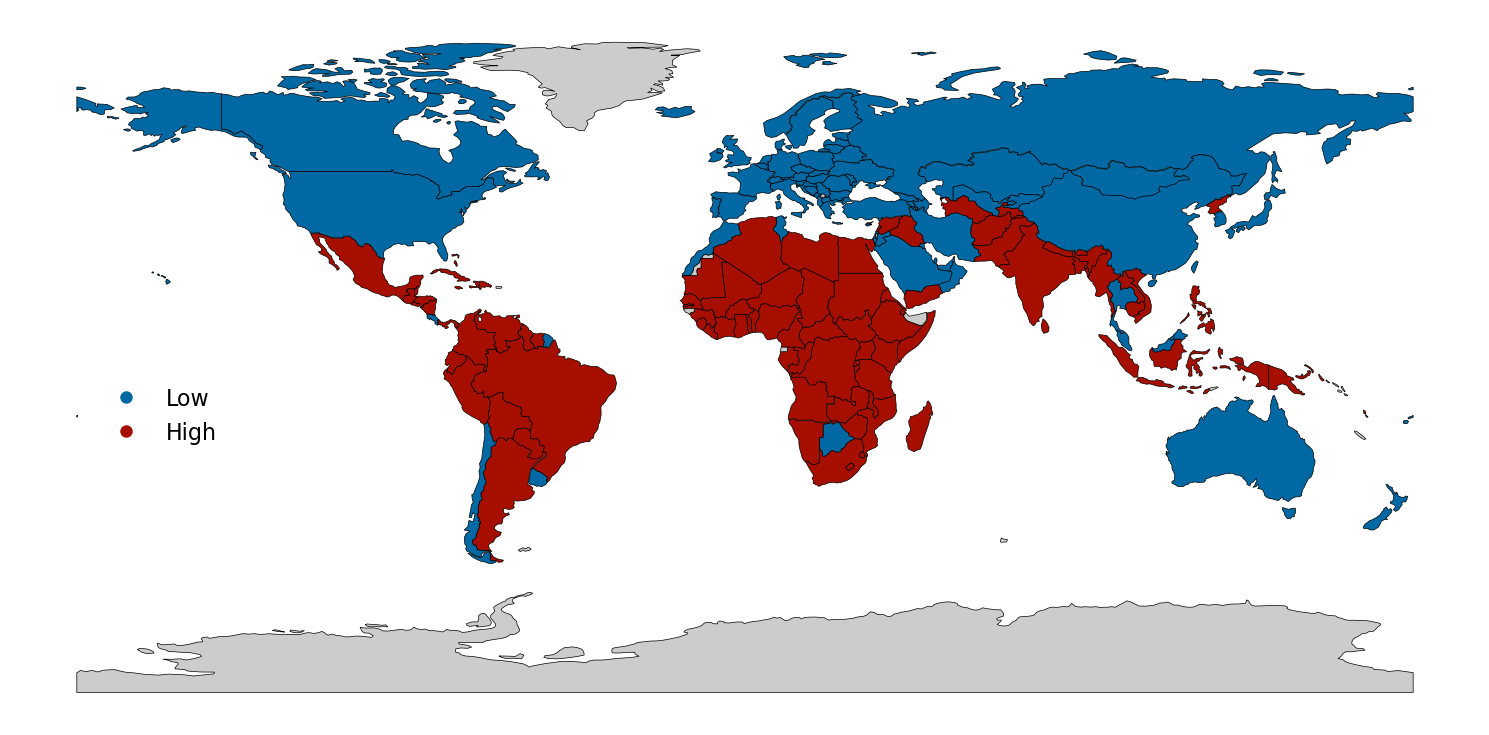

In [87]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

#HR_list_MRIOT.append('SSD')
#HR_list_MRIOT.append('SDN')

# Load the GeoJSON file
world = gpd.read_file("C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'High': '#a60f00' ,   # Dark Red
    'Low': '#0068a3',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in low_risk_countries:
        iso_to_color[code] = risk_levels['Low']
    elif code in high_risk_countries:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=risk_levels['Low'], markersize=10, label='Low'),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=risk_levels['High'], markersize=10, label='High')]

ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5), fontsize=16)  # Adjust the bbox_to_anchor for desired position


# Set bold title in the left corner
#plt.text(0.02, 1.05, "Local Climate Risk Index by Country", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "ND-Gain", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Extended Data\Figure1a.png') # 50, Extended Data

#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4c.png') #60 , Supp Mat 4 Panel c
#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4d.png') #40 , Supp Mat 4 Panel d
plt.tight_layout()
# Show the map
plt.show()

#HR_list_MRIOT.remove('SSD')
#HR_list_MRIOT.remove('SDN')

When threshold is different from 50 :

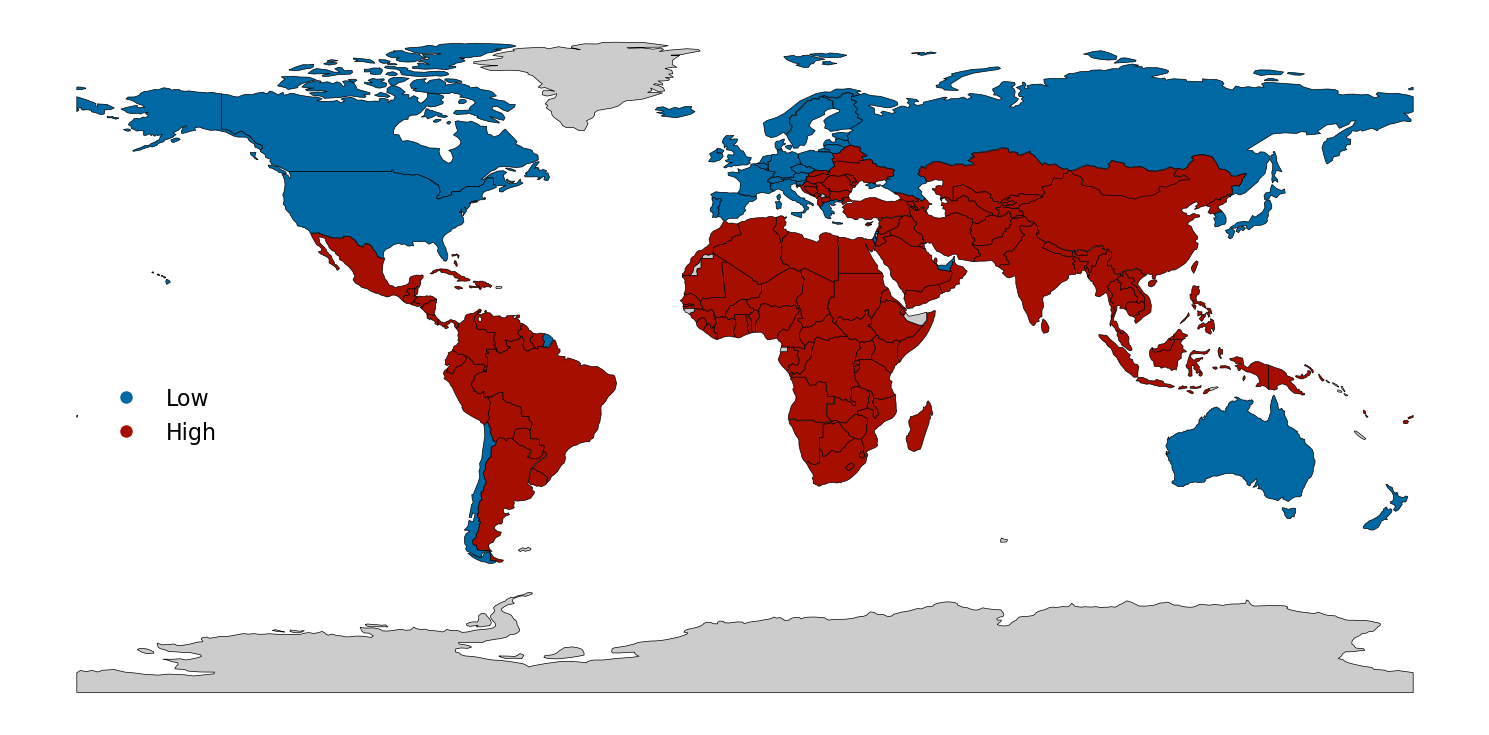

In [88]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

#HR_list_MRIOT.append('SSD')
#HR_list_MRIOT.append('SDN')

# Load the GeoJSON file
world = gpd.read_file("C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'High': '#a60f00' ,   # Dark Red
    'Low': '#0068a3',   # Vibrant Green
}

iso_to_color = {}

low_risk_countries = risk_level_lists_MRIOT['Low Risk']
high_risk_countries = risk_level_lists_MRIOT['High Risk']

for code in world['ISO_A3']:
    if code in low_risk_countries:
        iso_to_color[code] = risk_levels['Low']
    elif code in high_risk_countries:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=risk_levels['Low'], markersize=10, label='Low'),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=risk_levels['High'], markersize=10, label='High')]

ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5), fontsize=16)  # Adjust the bbox_to_anchor for desired position


# Set bold title in the left corner
#plt.text(0.02, 1.05, "Local Climate Risk Index by Country", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "ND-Gain", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Extended Data\Figure1a.png') # 50, Extended Data

#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4c.png') #60 , Supp Mat 4 Panel c
#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4d.png') #40 , Supp Mat 4 Panel d
plt.tight_layout()
# Show the map
plt.show()

#HR_list_MRIOT.remove('SSD')
#HR_list_MRIOT.remove('SDN')

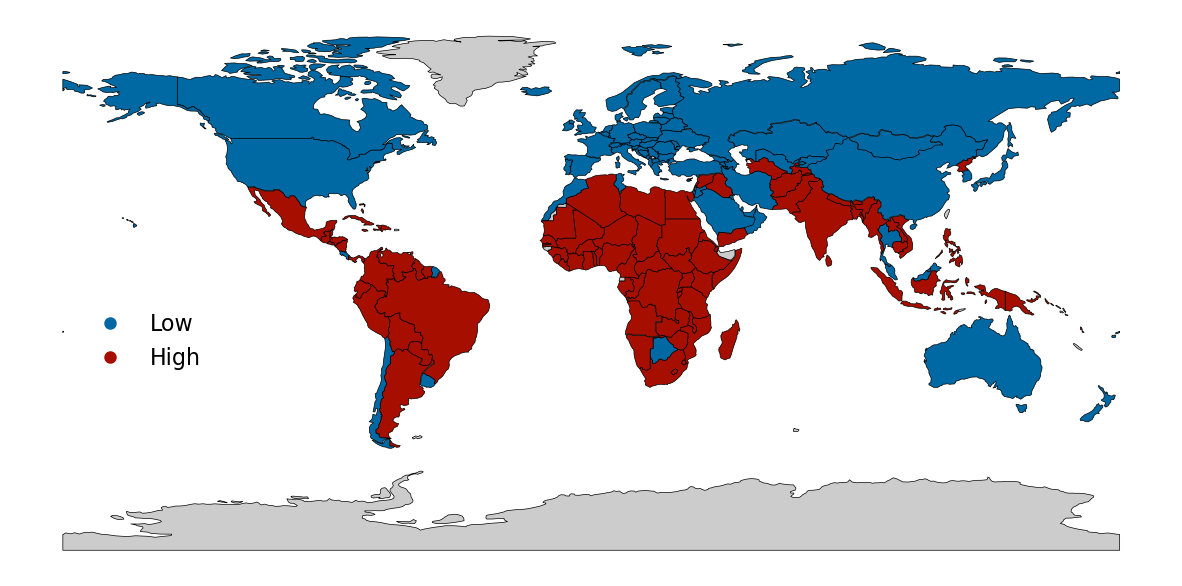

In [73]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA' 
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'
world.loc[(world['SOVEREIGNT'] == 'South Sudan'),'ISO_A3']='SDS'
world.loc[(world['SOVEREIGNT'] == 'Sudan'),'ISO_A3']='SUD'


risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in low_risk_countries:
        iso_to_color[code] = risk_levels['Low']
    elif code in high_risk_countries:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig(r'Figures\Extended Data\Figure1a.png')

# Show the map
plt.show()

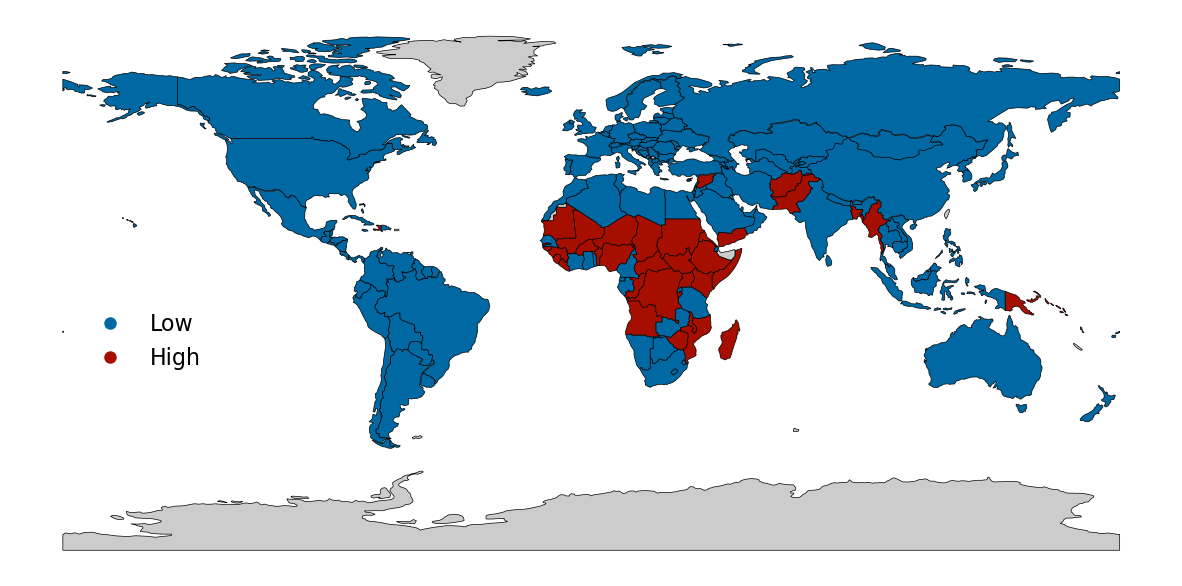

In [83]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

modified_local_climate_risk = create_local_climate_risk(local_climate_risk, 40)

df=modified_local_climate_risk

modified_low_risk_countries = list(df[df['Local Risk']=='Low Risk']['Country Code'])
modified_high_risk_countries = list(df[df['Local Risk']=='High Risk']['Country Code'])

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA' 
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'
world.loc[(world['SOVEREIGNT'] == 'South Sudan'),'ISO_A3']='SDS'
world.loc[(world['SOVEREIGNT'] == 'Sudan'),'ISO_A3']='SUD'


risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in modified_low_risk_countries:
        iso_to_color[code] = risk_levels['Low']
    elif code in modified_high_risk_countries:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure1c.png') #1c = 60
plt.savefig(r'Figures\Supp Mat\E\Figure1d.png') #1d = 40

# Show the map
plt.show()

Distribution of Local Risk

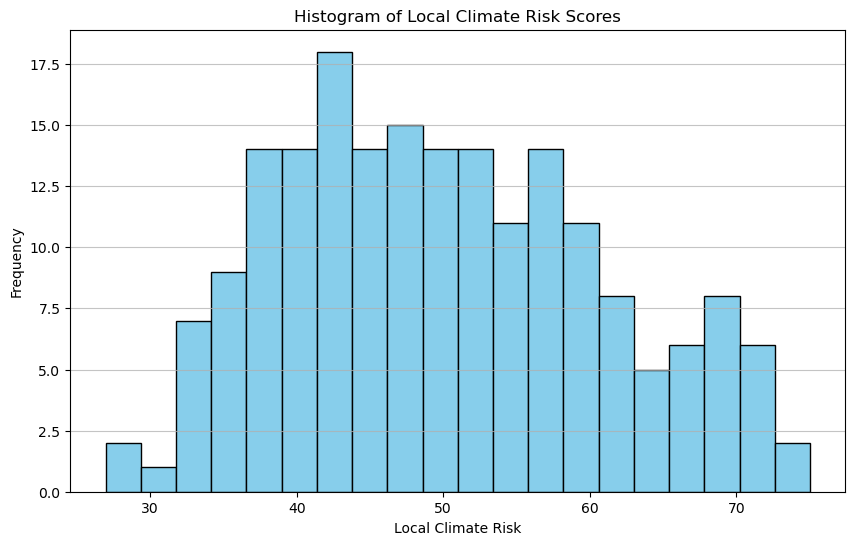

In [154]:
df = local_climate_risk
plt.figure(figsize=(10, 6))
plt.hist(df['Local Climate Risk'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Local Climate Risk Scores')
plt.xlabel('Local Climate Risk')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

# Other Data
---

## Developed, developing, least developed country lists

Data come from UNTCAD : https://unctadstat.unctad.org/EN/Classifications.html.

In addition,
- Macau and Hong-Kong have been attributed to the same development group as Chine (developing),
- Monaco is considered developed,
- Virgin Islands (British) has been put in the same group as the United Kingdom (developed).

Names have been changed marginally to be coherent with country names used in other data.

In [6]:
least_developed_countries = [
    "Afghanistan",
    "Bangladesh",
    "Bhutan",
    "Cambodia",
    "Lao People's Democratic Republic",
    "Myanmar",
    "Nepal",
    "Yemen",
    "Yemen, Arab Republic",
    "Yemen, Democratic",
    "Angola",
    "Benin",
    "Burkina Faso",
    "Burundi",
    "Central African Republic",
    "Chad",
    "Congo, Democratic Republic of the",
    "Djibouti",
    "Eritrea",
    "Ethiopia",
    "Ethiopia (...1991)",
    "Gambia",
    "Guinea",
    "Guinea-Bissau",
    "Lesotho",
    "Liberia",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mauritania",
    "Mozambique",
    "Niger",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "Somalia",
    "South Sudan",
    "Sudan",
    "Sudan (...2011)",
    "Tanzania, United Republic of",
    "Togo",
    "Uganda",
    "Zambia",
    "Comoros",
    "Haiti",
    "Kiribati",
    "Sao Tome and Principe",
    "Solomon Islands",
    "Timor-Leste",
    "Tuvalu"
]

developed_countries = [
    "Andorra",
    "Monaco",
    "San Marino",
    "Bermuda",
    "Taiwan",
    "Canada",
    "Greenland",
    "Saint Pierre and Miquelon",
    "United States of America",
    "Developed economies: Asia and Oceania",
    "Developed economies: Asia",
    "Israel",
    "Japan",
    "Korea, Republic of",
    "Developed economies: Oceania",
    "Australia",
    "Christmas Island",
    "Cocos (Keeling) Islands",
    "Heard Island and McDonald Islands",
    "New Zealand",
    "Norfolk Island",
    "United States Minor Outlying Islands",
    "Developed economies: Europe",
    "Albania",
    "Andorra",
    "Austria",
    "Belarus",
    "Belgium",
    "Bosnia and Herzegovina",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Czechoslovakia",
    "Denmark",
    "Estonia",
    "Faroe Islands",
    "Finland",
    "France",
    "Germany",
    "Germany, Democratic Republic of",
    "Germany, Federal Republic of",
    "Gibraltar",
    "Greece",
    "Holy See",
    "Hungary",
    "Iceland",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Moldova, Republic of",
    "Montenegro",
    "Netherlands",
    "North Macedonia",
    "Norway",
    "Poland",
    "Portugal",
    "Romania",
    "Russian Federation",
    "San Marino",
    "Serbia",
    "Serbia and Montenegro",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland", "Liechtenstein",
    "Ukraine",
    "Union of Soviet Socialist Republics",
    "United Kingdom of Great Britain and Northern Ireland",
    "Yugoslavia, Soc. Fed. Rep. of",
    "Monaco","Virgin Islands (British)","Taiwan, Province of China"
]

developing_countries = [
    "Algeria",
    "American Samoa",
    "Anguilla",
    "Antigua and Barbuda",
    "Argentina",
    "Armenia",
    "Aruba",
    "Azerbaijan",
    "Bahamas",
    "Bahrain",
    "Barbados",
    "Belize",
    "Bolivia (Plurinational State of)",
    "Bonaire, Sint Eustatius and Saba",
    "Botswana",
    "Bouvet Island",
    "Brazil",
    "British Indian Ocean Territory",
    "British Virgin Islands",
    "Brunei Darussalam",
    "Cabo Verde",
    "Cameroon",
    "Cayman Islands",
    "Chile",
    "China",
    "China, Hong Kong SAR",
    "China, Macao SAR",
    "Colombia",
    "Congo",
    "Cook Islands",
    "Costa Rica",
    "Côte d'Ivoire",
    "Cuba",
    "Curaçao",
    "Dominica",
    "Dominican Republic",
    "Ecuador",
    "Egypt",
    "El Salvador",
    "Equatorial Guinea",
    "Eswatini",
    "Falkland Islands (Malvinas)",
    "Fiji",
    "French Polynesia",
    "French Southern Territories",
    "Gabon",
    "Georgia",
    "Ghana",
    "Grenada",
    "Guam",
    "Guatemala",
    "Guyana",
    "Honduras",
    "India",
    "Indonesia",
    "Indonesia (...2002)",
    "Iran (Islamic Republic of)",
    "Iraq",
    "Jamaica",
    "Jordan",
    "Kazakhstan",
    "Kenya",
    "Korea (Democratic People's Republic of)",
    "Kuwait",
    "Kyrgyzstan",
    "Lebanon",
    "Libya",
    "Malaysia",
    "Maldives",
    "Marshall Islands",
    "Mauritius",
    "Mexico",
    "Micronesia (Federated States of)",
    "Mongolia",
    "Montserrat",
    "Morocco",
    "Namibia",
    "Nauru",
    "Netherlands Antilles",
    "New Caledonia",
    "Nicaragua",
    "Nigeria",
    "Niue",
    "Northern Mariana Islands",
    "Oman",
    "Pacific Islands, Trust Territory",
    "Pakistan",
    "Palau",
    "Panama",
    "Panama, Canal Zone",
    "Panama, excluding Canal Zone",
    "Papua New Guinea",
    "Paraguay",
    "Peru",
    "Philippines",
    "Pitcairn",
    "Qatar",
    "Saint Barthélemy",
    "Saint Helena",
    "Saint Kitts and Nevis",
    "Saint Lucia",
    "Saint Martin (French part)",
    "Saint Vincent and the Grenadines",
    "Samoa",
    "Saudi Arabia",
    "Seychelles",
    "Singapore",
    "Sint Maarten (Dutch part)",
    "South Africa",
    "South Georgia and South Sandwich Islands",
    "Sri Lanka",
    "Palestine, State of",
    "Suriname",
    "Syrian Arab Republic",
    "Tajikistan",
    "Thailand",
    "Tokelau",
    "Tonga",
    "Trinidad and Tobago",
    "Tunisia",
    "Turkey",
    "Turkmenistan",
    "Turks and Caicos Islands",
    "United Arab Emirates",
    "Uruguay",
    "Uzbekistan",
    "Vanuatu",
    "Venezuela (Bolivarian Republic of)",
    "Viet Nam",
    "Wallis and Futuna Islands",
    "Western Sahara",
    "Zimbabwe",    "China, Hong Kong SAR",
    "China, Macao SAR"
]

# Country-level analysis
----

## Inputs (Leontief)
----

### Code
----

In [7]:
import pandas as pd

Y = mriot.Y
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cForeign_Inputs_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cForeign_Inputs_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cForeign_Inputs_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cForeign_Inputs = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Inputs = pd.DataFrame(values, index=country_list)


for c in country_list:
    intrants_c = 0
    intrants_c_foreign = 0
    intrants_c_foreign_low = 0
    intrants_c_foreign_high = 0
    intrants_c_foreign_row = 0

    
    for s in sector_list:
        L_cs = L[c,s]
        y_cs = y[c,s]
        L_cs_foreign = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]
       
        intrants_cs = (L_cs*y_cs).sum()
        intrants_cs_foreign = (L_cs_foreign*y_cs).sum()
        intrants_cs_foreign_low = (L_cs_foreign_low*y_cs).sum()
        intrants_cs_foreign_high = (L_cs_foreign_high*y_cs).sum()
        intrants_cs_foreign_row = (L_cs_foreign_row*y_cs).sum()

        intrants_c=intrants_c + intrants_cs
        intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
        intrants_c_foreign_low = intrants_c_foreign_low + intrants_cs_foreign_low 
        intrants_c_foreign_high = intrants_c_foreign_high + intrants_cs_foreign_high  
        intrants_c_foreign_row = intrants_c_foreign_row + intrants_cs_foreign_row  

    cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
    cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
    cForeign_Inputs_high.loc[c] = intrants_c_foreign_high / intrants_c *100
    cForeign_Inputs_row.loc[c] = intrants_c_foreign_row / intrants_c *100

    cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cForeign_Inputs_low, cForeign_Inputs_high, cForeign_Inputs_row, cForeign_Inputs, cLocal_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    elif region in no_risk_countries:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

result['Country Code']=result['region']

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'
    
result['Development'] = result['Country'].apply(categorize_development)
result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes + Taiwan

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

#result.loc[result['Country Code'] == 'TWN', 'Population'] = 23923276

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_inputs_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_2764\3087698081.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_2764\3087698081.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '17.48698739933647' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_2764\3087698081.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.6067398886119553' has dtype incompatible with int64, please explicitly cast to a compatible dtyp

In [8]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_inputs_leontief.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_inputs_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_inputs_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_inputs_leontief = pickle.load(f)

In [59]:
df=resulting_dataframe_country_inputs_leontief
median_high_risk_developed_inputs = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()
median_high_risk_developed_inputs

1.3382176290910341

### Plot
----

### Distributions
-----

#### Exposure

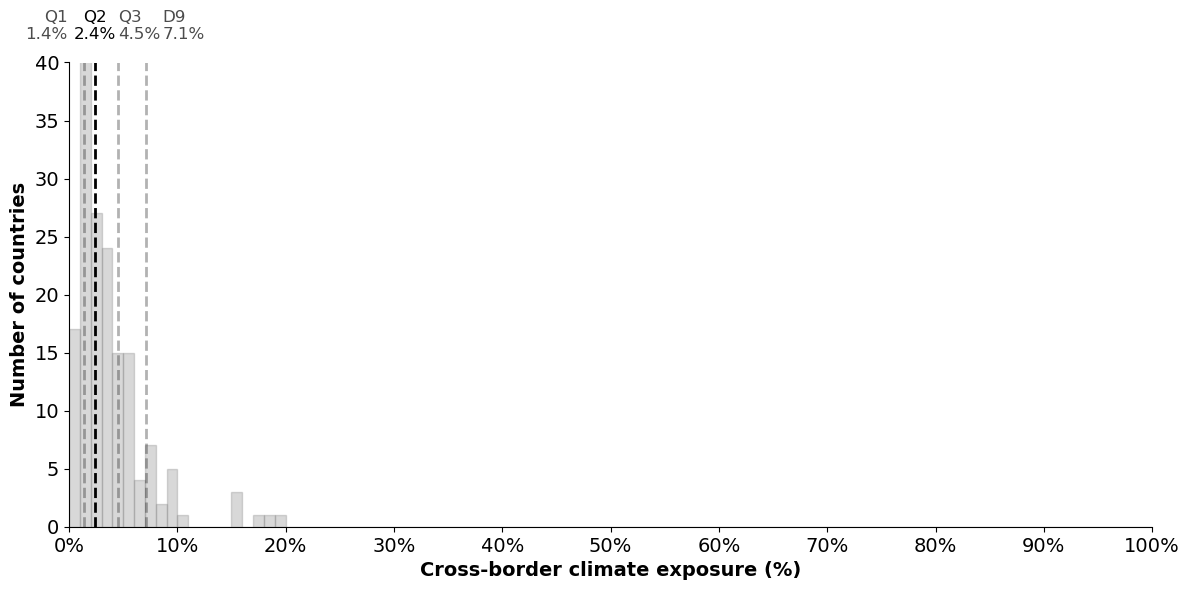

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
#df = resulting_dataframe_country_exports_leontief_CI
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Count rows for the entire dataset
total_row_counts = count_rows_in_bins(df, bins, 'High Risk Exposure (%)')
data_to_plot = total_row_counts
color = 'grey'

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)

# Calculate and plot median and quartiles
flat_data = resulting_dataframe_country_inputs_leontief['High Risk Exposure (%)']
median_value = np.median(flat_data)
first_quartile = np.percentile(flat_data, 25)
third_quartile = np.percentile(flat_data, 75)
ninth_decile = np.percentile(flat_data, 90)

plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

# Annotate the lines
plt.text(median_value, 42 , f'Q2\n{median_value:.1f}%', horizontalalignment='center', color='black',fontsize=12)
plt.text(first_quartile-1.5, 42, f'Q1\n{first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
plt.text(third_quartile, 42, f'Q3\n{third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)
plt.text(ninth_decile+1.5, 42, f'D9\n{ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14,fontweight='bold')
plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()

#plt.savefig(r"Figures\Supp Mat\B\Fig1c.png")

plt.show()

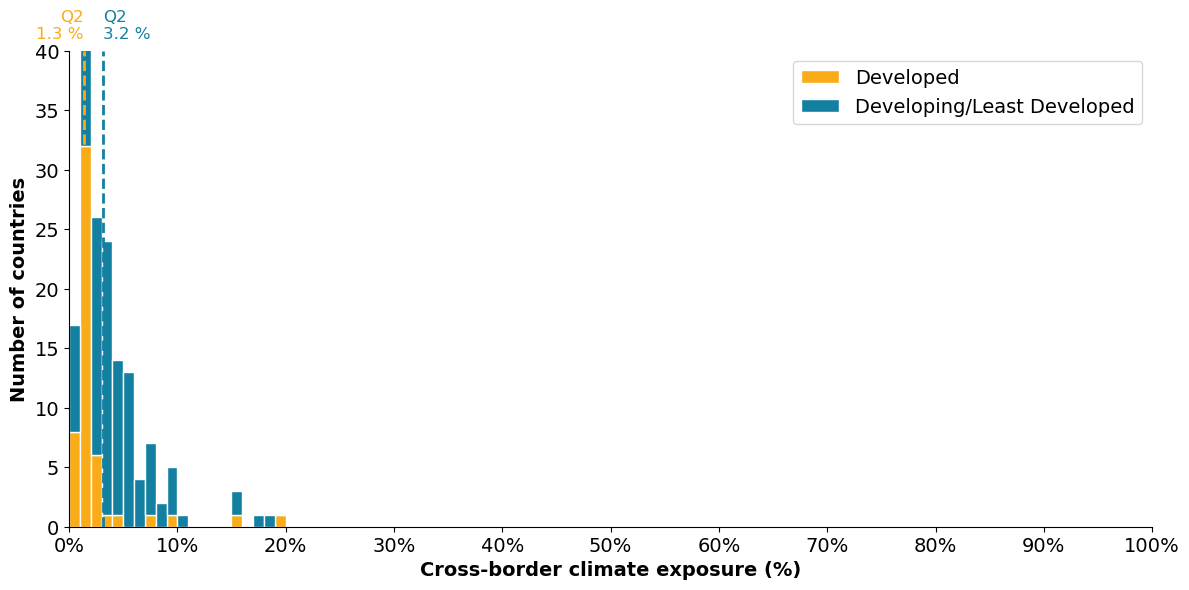

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
#bins = np.linspace(0, round(df['High Risk'].max(), 0) + 2, 30)
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']

developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk Exposure (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk Exposure (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]

# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk Exposure (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk Exposure (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)

plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='left', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='right', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.legend(fontsize=14)

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig4a.png") # Intermediate Cons
#plt.savefig(r"Figures\Supp Mat\C\Fig4b.png") # Final Cons
#plt.savefig(r"Figures\Supp Mat\C\Fig4c.png") # Exports interm
#plt.savefig(r"Figures\Supp Mat\C\Fig4d.png") # Exports fin


plt.show()

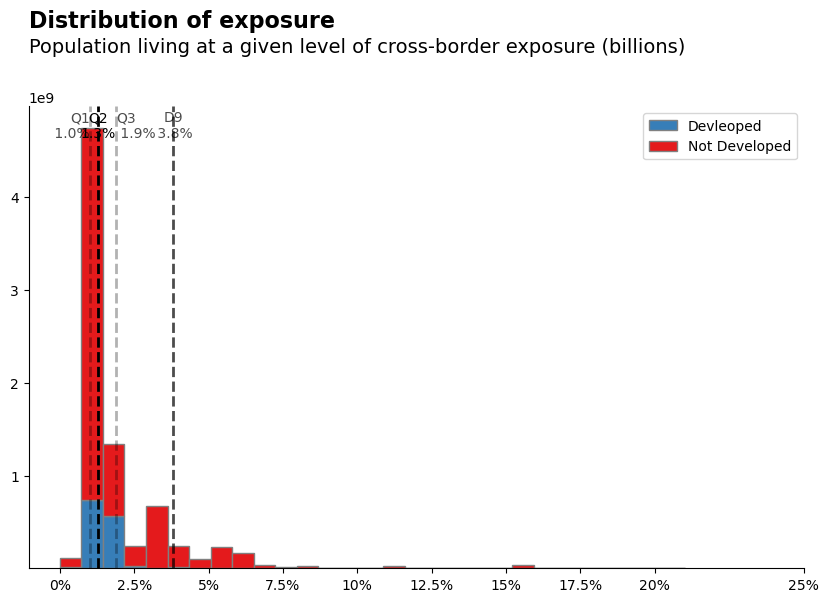

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def population_sum_in_bins(d, bins, column_name):
    bin_sums = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        bin_sum = bin_d['Population'].sum()
        bin_sums.append(bin_sum)
    return bin_sums

color_palette = sns.color_palette("Set1", 7)


def plot_population_distribution(df, graph_type='total'):
    """
    Plots the specified type of population distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    """
    # Define the number of bins and calculate the bin edges
    bins = np.linspace(0, round(df['High Risk Exposure (%)'].max(),0)+2, 30)

    if graph_type == 'total':
        # Calculate population sums for the entire dataset
        total_population_sums = population_sum_in_bins(df, bins, 'High Risk Exposure (%)')
        data_to_plot = total_population_sums
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        #low_risk_df = df[df['Local Risk'] == 'Low Risk']
        #high_risk_df = df[df['Local Risk'] == 'High Risk']
        #label = ['Low Local Risk', 'High Local Risk']

        low_risk_df = df[df['Development'] == 'Developed']
        high_risk_df = df[df['Development'] != 'Developed']
        label = ['Devleoped', 'Not Developed']
        low_risk_population_sums = population_sum_in_bins(low_risk_df, bins, 'High Risk Exposure (%)')
        high_risk_population_sums = population_sum_in_bins(high_risk_df, bins, 'High Risk Exposure (%)')
        data_to_plot = [low_risk_population_sums, high_risk_population_sums]
        color = [color_palette[1], color_palette[0]]  

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(10, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center',edgecolor='grey',alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center',edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center',edgecolor='grey')
        plt.legend()
    
    # Calculate population sums for the entire dataset
    total_population_sums = population_sum_in_bins(df, bins, 'High Risk Exposure (%)')

    # Scale factor to avoid memory issues (adjust if necessary)
    scale_factor = 10000

    # Replicate 'High Risk Exposure (%)' values according to scaled 'Population (2023)'
    weighted_risk_values = np.repeat(df['High Risk Exposure (%)'], (df['Population'] / scale_factor).astype(int))

    # Calculate the weighted median, quartiles, and deciles
    weighted_median = np.median(weighted_risk_values)
    weighted_first_quartile = np.percentile(weighted_risk_values, 25)
    weighted_third_quartile = np.percentile(weighted_risk_values, 75)
    weighted_ninth_decile = np.percentile(weighted_risk_values, 90)
    
    # Draw lines for weighted median and quartiles
    plt.axvline(weighted_median, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(weighted_first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.7)

    # Find the maximum height of the bars for positioning the text
    max_height = max(max(data_to_plot)) if graph_type == 'risk_comparison' else max(data_to_plot)
    text_height = max_height * 1.15  # Place text slightly above the maximum bar height

    # Annotate the lines
    plt.text(weighted_median, text_height, f'Q2\n{weighted_median:.1f}%', horizontalalignment='center', color='black', verticalalignment='bottom')
    plt.text(weighted_first_quartile, text_height, f'Q1\n {weighted_first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_third_quartile, text_height, f'Q3\n {weighted_third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_ninth_decile, text_height, f'D9\n {weighted_ninth_decile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0,2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20, 25]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])

    # Titles
    plt.text(0, 1.21, "Distribution of exposure", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
    plt.text(0, 1.15, "Population living at a given level of cross-border exposure (billions)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

    plt.show()

# Usage examples
#graph = "total" # for basic graph
graph = 'risk_comparison' # population divided by local risk

plot_population_distribution(df, graph_type=graph) 

In [17]:
df = resulting_dataframe_country_exports_leontief_CI

median_foreign = df['Foreign (%)'].median()
median_share = df['Share of Risky Trade Partners (%)'].median()

df[(df['Foreign (%)'] > median_foreign) & 
   (df['Share of Risky Trade Partners (%)'] > median_share) & 
   (df['Local Risk'] == 'Low Risk')].sort_values(by='Population',ascending=False)

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
43,Thailand,THA,52.278140,Low Risk,East Asia & Pacific,Upper middle income,71801279.0,Developing,22.751716,5.279923,0,28.050857,71.949143,18.835585
83,Portugal,PRT,62.805697,Low Risk,Europe & Central Asia,High income,10352260.0,Developed,16.987992,3.040406,0,20.043108,79.956892,15.180474
12,United Arab Emirates,ARE,60.729262,Low Risk,Middle East & North Africa,High income,9516871.0,Developing,31.353505,8.499607,0,39.864618,60.135382,21.327336
5,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,38.031800,12.281789,0,50.352579,49.647421,24.410481
85,Costa Rica,CRI,54.009891,Low Risk,Latin America & Caribbean,Upper middle income,5212173.0,Developing,14.341231,5.389433,0,19.744106,80.255894,27.315010
31,Kuwait,KWT,55.414317,Low Risk,Middle East & North Africa,High income,4310108.0,Developing,27.345690,4.584313,0,31.949322,68.050678,14.357382
32,Georgia,GEO,58.467932,Low Risk,Europe & Central Asia,Upper middle income,3698729.0,Developing,25.794520,4.915814,0,30.867713,69.132287,16.007035
86,Armenia,ARM,56.880962,Low Risk,Europe & Central Asia,Upper middle income,2777970.0,Developing,16.833879,2.806611,0,19.702176,80.297824,14.289925
54,Botswana,BWA,50.838296,Low Risk,Sub-Saharan Africa,Upper middle income,2675352.0,Developing,21.577985,4.318606,0,26.004128,73.995872,16.676349
6,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Unknown,27.457265,21.683864,0,49.827827,50.172173,44.125694


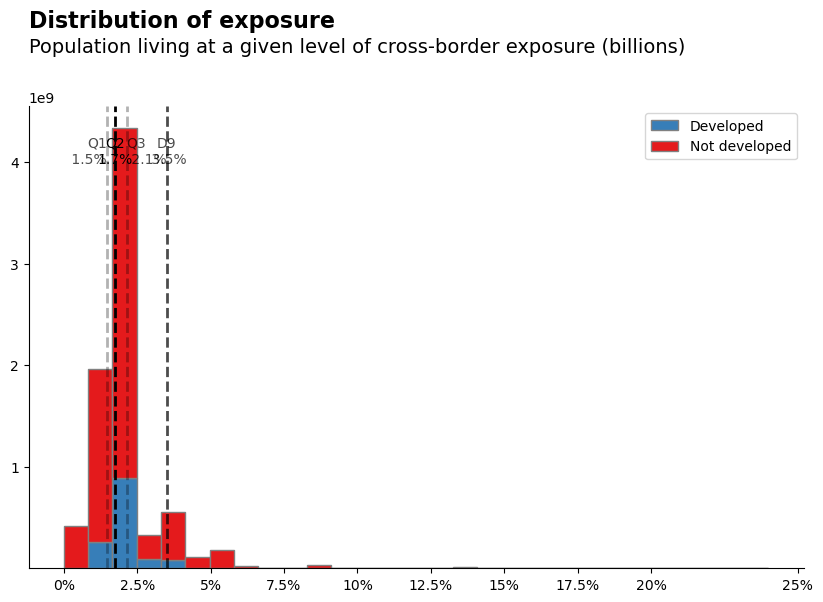

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_exports_leontief_CI

def population_sum_in_bins(d, bins, column_name):
    bin_sums = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        bin_sum = bin_d['Population'].sum()
        bin_sums.append(bin_sum)
    return bin_sums

color_palette = sns.color_palette("Set1", 7)


def plot_population_distribution(df, graph_type='total'):
    """
    Plots the specified type of population distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    """
    # Define the number of bins and calculate the bin edges
    bins = np.linspace(0, round(df['High Risk Exposure (%)'].max(),0)+2, 30)

    if graph_type == 'total':
        # Calculate population sums for the entire dataset
        total_population_sums = population_sum_in_bins(df, bins, 'High Risk Exposure (%)')
        data_to_plot = total_population_sums
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Development'] == 'Developed']
        high_risk_df = df[df['Development'] != 'Developed']
        low_risk_population_sums = population_sum_in_bins(low_risk_df, bins, 'High Risk Exposure (%)')
        high_risk_population_sums = population_sum_in_bins(high_risk_df, bins, 'High Risk Exposure (%)')
        data_to_plot = [low_risk_population_sums, high_risk_population_sums]
        color = [color_palette[1], color_palette[0]]  
        label = ['Developed', 'Not developed']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(10, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center',edgecolor='grey',alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center',edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center',edgecolor='grey')
        plt.legend()
    
    # Calculate population sums for the entire dataset
    total_population_sums = population_sum_in_bins(df, bins, 'High Risk Exposure (%)')

    # Scale factor to avoid memory issues (adjust if necessary)
    scale_factor = 10000

    # Replicate 'High Risk Exposure (%)' values according to scaled 'Population (2023)'
    weighted_risk_values = np.repeat(df['High Risk Exposure (%)'], (df['Population'] / scale_factor).astype(int))

    # Calculate the weighted median, quartiles, and deciles
    weighted_median = np.median(weighted_risk_values)
    weighted_first_quartile = np.percentile(weighted_risk_values, 25)
    weighted_third_quartile = np.percentile(weighted_risk_values, 75)
    weighted_ninth_decile = np.percentile(weighted_risk_values, 90)
    
    # Draw lines for weighted median and quartiles
    plt.axvline(weighted_median, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(weighted_first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.7)

    # Find the maximum height of the bars for positioning the text
    max_height = max(max(data_to_plot)) if graph_type == 'risk_comparison' else max(data_to_plot)
    text_height = max_height * 1.15  # Place text slightly above the maximum bar height

    # Annotate the lines
    plt.text(weighted_median, text_height, f'Q2\n{weighted_median:.1f}%', horizontalalignment='center', color='black', verticalalignment='bottom')
    plt.text(weighted_first_quartile, text_height, f'Q1\n {weighted_first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_third_quartile, text_height, f'Q3\n {weighted_third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_ninth_decile, text_height, f'D9\n {weighted_ninth_decile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0,2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20, 25]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])

    # Titles
    plt.text(0, 1.21, "Distribution of exposure", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
    plt.text(0, 1.15, "Population living at a given level of cross-border exposure (billions)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

    plt.show()

# Usage examples
#graph = "total" # for basic graph
graph = 'risk_comparison' # population divided by local risk

plot_population_distribution(df, graph_type=graph) 

#### Share of risky trade partners
----

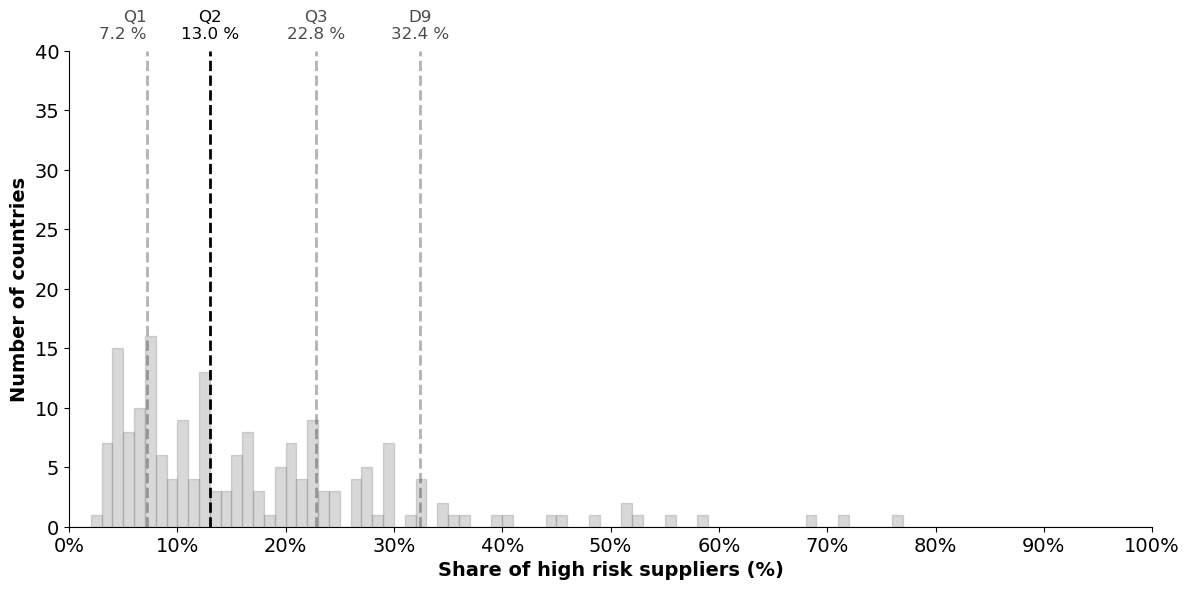

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'Share of Risky Trade Partners (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Share of Risky Trade Partners (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = resulting_dataframe_country_inputs_leontief['Share of Risky Trade Partners (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 41, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 41, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 41, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 41, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Share of high risk suppliers (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    plt.savefig(r"Figures\Supp Mat\B\Fig3c.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

In [410]:
df = resulting_dataframe_country_inputs_leontief
median_high_risk = df[(df['Region'] != 'Europe & Central Asia') & (df['Development'] == 'Developed')]['Share of Risky Trade Partners (%)'].median()
median_high_risk

28.889774600845342

By population :

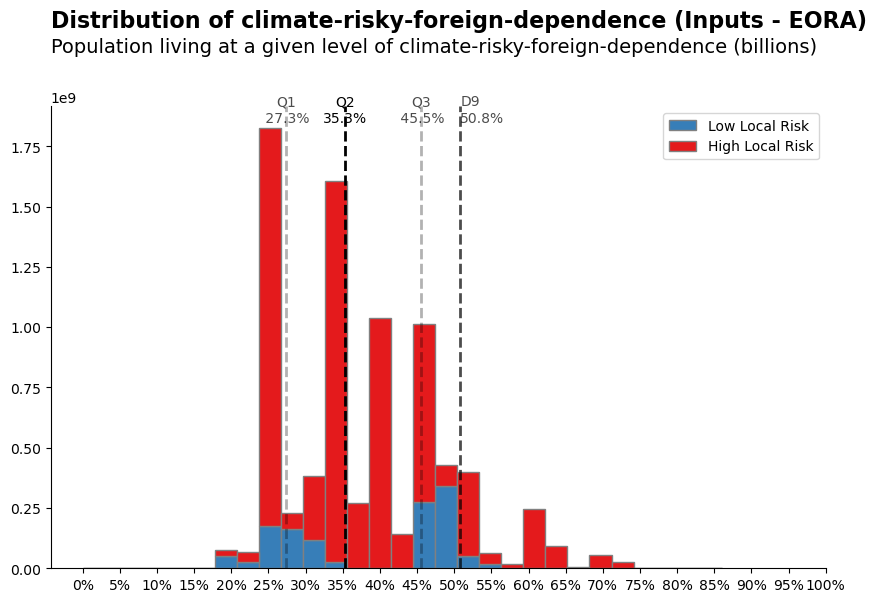

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def population_sum_in_bins(d, bins, column_name):
    bin_sums = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        bin_sum = bin_d['Population (2023)'].sum()
        bin_sums.append(bin_sum)
    return bin_sums

color_palette = sns.color_palette("Set1", 7)


def plot_population_distribution(df, graph_type='total'):
    """
    Plots the specified type of population distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    """
    # Define the number of bins and calculate the bin edges
    bins = np.linspace(0, round(df['Share of Risky Trade Partners (%)'].max(),0)+2, 30)

    if graph_type == 'total':
        # Calculate population sums for the entire dataset
        total_population_sums = population_sum_in_bins(df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = total_population_sums
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'High Risk']
        low_risk_population_sums = population_sum_in_bins(low_risk_df, bins, 'Share of Risky Trade Partners (%)')
        high_risk_population_sums = population_sum_in_bins(high_risk_df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = [low_risk_population_sums, high_risk_population_sums]
        color = [color_palette[1], color_palette[0]]  
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(10, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center',edgecolor='grey',alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center',edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center',edgecolor='grey')
        plt.legend()
    
    # Calculate population sums for the entire dataset
    total_population_sums = population_sum_in_bins(df, bins, 'Share of Risky Trade Partners (%)')

    # Scale factor to avoid memory issues (adjust if necessary)
    scale_factor = 10000

    # Replicate 'Share of Risky Trade Partners (%)' values according to scaled 'Population (2023)'
    weighted_risk_values = np.repeat(df['Share of Risky Trade Partners (%)'], (df['Population (2023)'] / scale_factor).astype(int))

    # Calculate the weighted median, quartiles, and deciles
    weighted_median = np.median(weighted_risk_values)
    weighted_first_quartile = np.percentile(weighted_risk_values, 25)
    weighted_third_quartile = np.percentile(weighted_risk_values, 75)
    weighted_ninth_decile = np.percentile(weighted_risk_values, 90)
    
    # Draw lines for weighted median and quartiles
    plt.axvline(weighted_median, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(weighted_first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.7)

    # Find the maximum height of the bars for positioning the text
    max_height = max(max(data_to_plot)) if graph_type == 'risk_comparison' else max(data_to_plot)
    text_height = max_height * 5.4  # Place text slightly above the maximum bar height

    # Annotate the lines
    plt.text(weighted_median, text_height, f'Q2\n{weighted_median:.1f}%', horizontalalignment='center', color='black', verticalalignment='bottom')
    plt.text(weighted_first_quartile, text_height, f'Q1\n {weighted_first_quartile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_third_quartile, text_height, f'Q3\n {weighted_third_quartile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_ninth_decile, text_height, f'D9\n{weighted_ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7, verticalalignment='bottom')
    
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = list(range(0, 101, 5))
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])

    # Titles
    plt.text(0, 1.21, "Distribution of climate-risky-foreign-dependence (Inputs - EORA)", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
    plt.text(0, 1.15, "Population living at a given level of climate-risky-foreign-dependence (billions)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

    plt.show()

# Usage examples
#graph = "total" # for basic graph
graph = 'risk_comparison' # population divided by local risk

plot_population_distribution(df, graph_type=graph) 

### Correlation Risk & Climate-Foreign-Dependence

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\1566231770.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


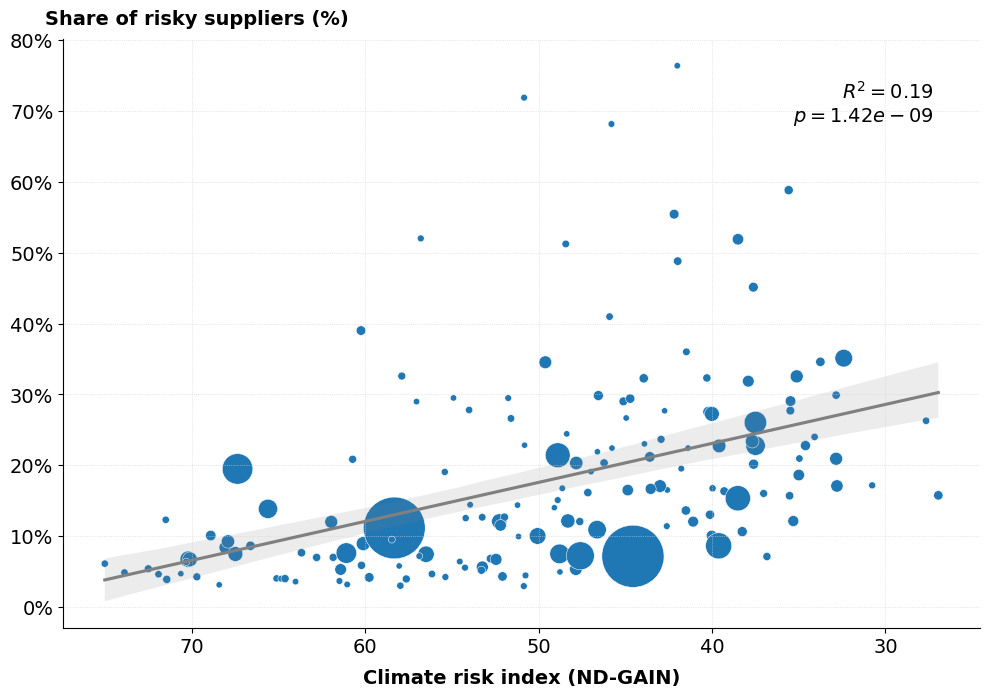

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Data setup (assuming 'result' is already your DataFrame)
result = resulting_dataframe_country_inputs_leontief
result = result.dropna(subset=['Local Climate Risk'])

# Define a custom color palette
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot configuration
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x='Local Climate Risk', 
    y='Share of Risky Trade Partners (%)',
    data=result, 
    palette=custom_palette, 
    size='Population', 
    sizes=(20, 2000)
)

# Extract handles and labels for legend
handles, labels = scatter.get_legend_handles_labels()
num_regions = len(result['Country'].unique())

# Legend configuration
plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
plt.legend().set_visible(False)

# Get current axes, suppress spines, reverse x-axis
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.invert_xaxis()  # Reverses the x-axis

# Regression and R-squared calculations
x = result['Local Climate Risk']
y = result['Share of Risky Trade Partners (%)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')

# Adding text for regression details
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Additional formatting
fmt = lambda x, _: '{:.0f}%'.format(x)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')
ax.set_ylabel('')
plt.subplots_adjust(right=0.75)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.text(0.5, -0.1, 'Climate risk index (ND-GAIN)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Save and show the plot
plt.tight_layout()
plt.savefig(r"Figures\Supp Mat\C\Fig3e.png")
plt.show()

In [62]:
resulting_dataframe_country_inputs_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
1,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,37.233610,15.576317,5.706165,58.516092,41.483908,29.495055
2,"China, Hong Kong SAR",HKG,NaN,Unkonwn,East Asia & Pacific,High income,7350409.0,Developing,52.654622,2.770289,1.929616,57.354527,42.645473,4.998273
3,San Marino,SMR,NaN,Unkonwn,Europe & Central Asia,High income,33642.0,Developed,24.079857,19.126293,7.800318,51.006468,48.993532,44.267525
4,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,40.318116,5.668660,2.124597,48.111373,51.888627,12.326718
5,Luxembourg,LUX,68.424627,Low Risk,Europe & Central Asia,High income,657569.0,Developed,45.154157,1.469545,0.250341,46.874044,53.125956,3.151927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,1.040105,0.550403,0.123794,1.714303,98.285697,34.605484
184,South Sudan,SDS,32.845793,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.968992,0.413513,0.145162,1.527666,98.472334,29.910400
185,Guyana,GUY,44.952938,High Risk,Latin America & Caribbean,High income,813834.0,Developing,0.891494,0.324433,0.009092,1.225018,98.774982,26.681940
186,Myanmar,MMR,37.686660,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.602205,0.184094,0.038447,0.824747,99.175253,23.412739


### XY Figure
-----

#### Plot
----

In [98]:
resulting_dataframe_country_inputs_leontief

,Low Risk,High Risk,ROW,Foreign (%),Local (%)
region,,,,,
AFG,17.904652,3.606740,0,21.546055,78.453945
ALB,24.302745,1.130166,0,25.479742,74.520258
DZA,24.746722,1.394990,0,26.149411,73.850589
AND,13.682891,1.449840,0,15.207963,84.792037
AGO,12.212982,5.645298,0,17.868525,82.131475
...,...,...,...,...,...
VEN,10.569357,3.930946,0,14.517196,85.482804
VNM,42.640416,2.899593,0,45.558563,54.441437
YEM,14.746697,3.280914,0,18.045229,81.954771


C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

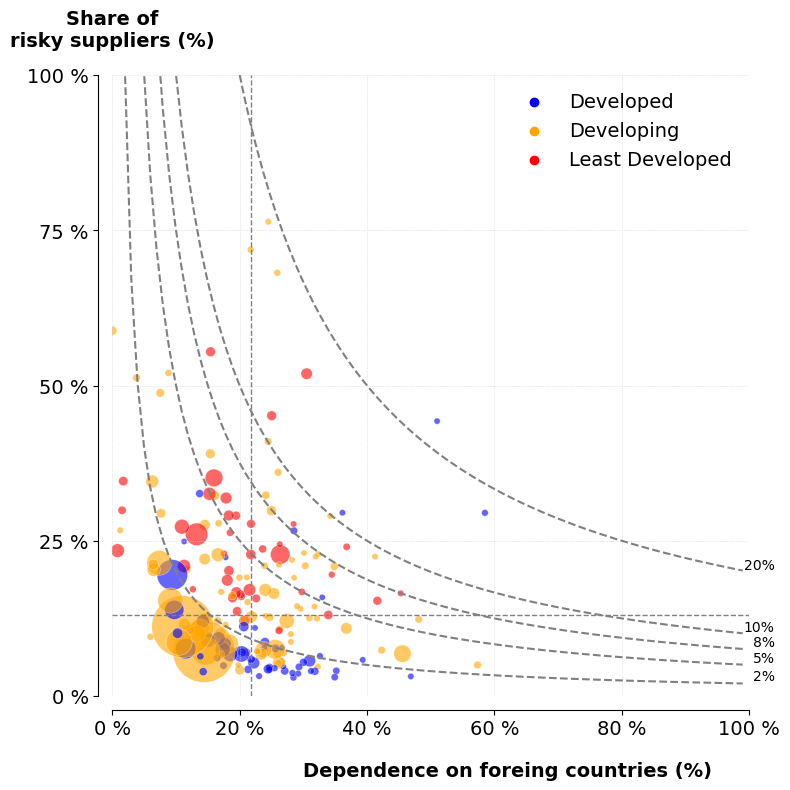

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_inputs_leontief

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='Share of Risky Trade Partners (%)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        frameon=False,      # Suppress the legend box
        fontsize=14
    )
    
median_x = result['Foreign (%)'].median()
median_y = result['Share of Risky Trade Partners (%)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreing countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1e.png")

plt.show()

Moyenne sur les pays développés 

In [95]:
result = resulting_dataframe_country_inputs_leontief
print('Moyenne du high risk sur les pays développés : ',result[result['Development'] == 'Developed']['High Risk'].median().round(2),'%')

AttributeError: 'float' object has no attribute 'round'

In [96]:
result[result['Development'] == 'Developed']['High Risk'].quantile(0.8)

2.033522316288492

In [307]:
first_quartile = result['High Risk'].quantile(0.5)
first_quartile

5.825964202371849

#### Export data

In [131]:
df = resulting_dataframe_country_exports_leontief_CF

# Importing the pandas library
import pandas as pd

median_high_risk_relative = df['High Risk Exposure (%)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk trade partners' if x > median_high_risk_relative else 'Low-risk trade partners')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

# Exporting to an Excel file
#df.to_excel(r"Figures\fig1e.xlsx", index=False) # Inputs 
#df.to_excel(r"Figures\fig1f.xlsx", index=False) # Cons 
#df.to_excel(r"Figures\fig1g.xlsx", index=False) # E CI
#df.to_excel(r"Figures\fig1h.xlsx", index=False) # E CF

In [212]:
resulting_dataframe_country_cons_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Ethiopia,ETH,37.492203,High Risk,Sub-Saharan Africa,Low income,126527060.0,Least Developed,74.975818,24.166406,0,99.142224,0.857776,24.375493
1,Belarus,BLR,57.893267,Low Risk,Europe & Central Asia,Upper middle income,9167767.0,Developed,76.190910,15.017349,0,91.208259,8.791741,16.464900
2,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,43.838517,21.995241,0,65.833758,34.166242,33.410277
3,Malta,MLT,58.044556,Low Risk,Middle East & North Africa,High income,524909.0,Developed,52.274643,2.307303,0,54.581946,45.418054,4.227228
4,Hong Kong,HKG,58.324542,Low Risk,East Asia & Pacific,High income,7350409.0,Developing,44.185189,2.522704,0,46.707893,53.292107,5.401023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,Sudan,SUD,32.845793,High Risk,Sub-Saharan Africa,Low income,48109006.0,Least Developed,1.189107,0.391537,0,1.580643,98.419357,24.770714
175,South Sudan,SDS,32.845793,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.299894,0.177957,0,0.477851,99.522149,37.241126
176,Myanmar,MMR,37.686660,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.345873,0.114560,0,0.460433,99.539567,24.880973
177,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.072472,0.069136,0,0.141609,99.858391,48.822056


#### Analyzing Quadrants
-----

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3493266780.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3493266780.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 

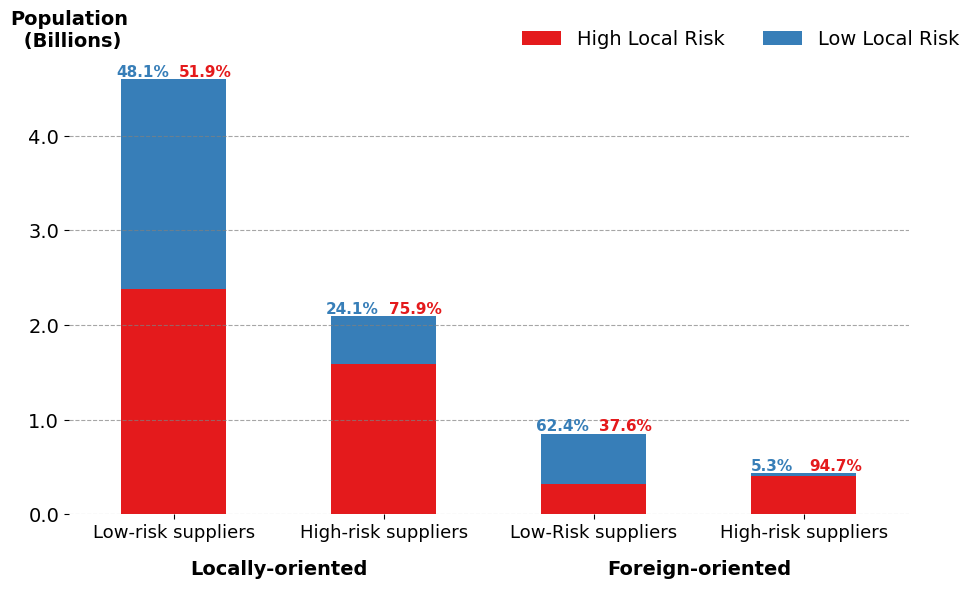

In [119]:
df = resulting_dataframe_country_inputs_leontief
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.9e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot

# Show the plot
plt.savefig(r"Figures\Supp Mat\C\Fig2e.png")

plt.show()

In [105]:
population_by_risk

Local Risk                                           High Risk    Low Risk
Foreign (%) Category High Risk (relative) Category                        
Locally-oriented     Low-risk suppliers             2385833260  2232168993
                     High-risk suppliers            1586500328   503904355
Foreign-oriented     Low-risk suppliers              319699563   538774621
                     High-risk suppliers             409474196    22779598

## Consumption
----

### Consumption (Direct)
---

In [132]:
import pandas as pd

final_production = mriot.Y.copy()


Y = mriot.Y.copy()
final_production_by_destination = Y.groupby(level='region', axis=1).sum()

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

# Pour chaque pays, quelle pondération de la consommation finale ?
####

values = {'Low Risk': [0] * country_list.size}
cConsoFin_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cConsoFin_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cConsoFin_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for c in country_list:
    cConsoFin = final_production_by_destination[c]
    cConsoFin_tot = final_production_by_destination[c].sum()
    country_list_except = [x for x in country_list if x != c]
    for cc in country_list_except:
        for s in sector_list:
            if cc in low_risk_countries:
                cConsoFin_low.loc[c] = cConsoFin_low.loc[c]+cConsoFin.loc[cc,s]
            if cc in high_risk_countries:
                cConsoFin_high.loc[c] = cConsoFin_high.loc[c]+cConsoFin.loc[cc,s]
            if cc in ['ROW']:
                cConsoFin_row.loc[c] = cConsoFin_row.loc[c]+cConsoFin.loc[cc,s]
    cConsoFin_Foreign.loc[c] = cConsoFin_low.loc[c].iloc[0] + cConsoFin_high.loc[c].iloc[0]+cConsoFin_row.loc[c].iloc[0]
    cConsoFin_Local.loc[c] = cConsoFin_tot - cConsoFin_Foreign.loc[c].iloc[0]
    
    #Ratios
    cConsoFin_low.loc[c]=cConsoFin_low.loc[c]/cConsoFin_tot*100
    cConsoFin_high.loc[c]=cConsoFin_high.loc[c]/cConsoFin_tot*100
    cConsoFin_row.loc[c]=cConsoFin_row.loc[c]/cConsoFin_tot*100
    
    cConsoFin_Local.loc[c]=cConsoFin_Local.loc[c]/cConsoFin_tot*100
    cConsoFin_Foreign.loc[c]=cConsoFin_Foreign.loc[c]/cConsoFin_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_low, cConsoFin_high,cConsoFin_row, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_direct = pd.concat(dataframes_to_concat, axis=1)


# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_direct.sort_values('Foreign (%)', ascending=False).reset_index()


# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

result=result[result['Local Risk']!='Unknown']

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

resulting_dataframe_country_cons_direct = result

C:\Users\delah\AppData\Local\Temp\ipykernel_2720\3916749271.py:7: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_2720\3916749271.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '76.23999' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_low.loc[c] = cConsoFin_low.loc[c]+cConsoFin.loc[cc,s]
C:\Users\delah\AppData\Local\Temp\ipykernel_2720\3916749271.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '29.219009' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_high.loc[c] = cConsoFin_high.loc[c]+cConsoFin.loc[cc,s]
C:\Users\delah\AppData\Local\Temp\ipykernel_2720\39

In [133]:
resulting_dataframe_country_cons_direct

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Ethiopia,ETH,37.492203,High Risk,Sub-Saharan Africa,Low income,126527060.0,Least Developed,72.396545,26.740335,0,99.136880,0.863120,26.973145
1,Belarus,BLR,57.893267,Low Risk,Europe & Central Asia,Upper middle income,9167767.0,Developed,75.576955,15.593857,0,91.170812,8.829188,17.104001
2,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,41.225111,24.008444,0,65.233555,34.766445,36.803827
3,Malta,MLT,58.044556,Low Risk,Middle East & North Africa,High income,524909.0,Developed,52.931198,1.662114,0,54.593312,45.406688,3.044538
4,Hong Kong,HKG,58.324542,Low Risk,East Asia & Pacific,High income,7350409.0,Developing,44.761709,2.147851,0,46.909560,53.090440,4.578706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,Sudan,SUD,32.845793,High Risk,Sub-Saharan Africa,Low income,48109006.0,Least Developed,1.156136,0.419148,0,1.575284,98.424716,26.607785
175,South Sudan,SDS,32.845793,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.278589,0.194563,0,0.473152,99.526848,41.120598
176,Myanmar,MMR,37.686660,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.335687,0.122624,0,0.458310,99.541690,26.755614
177,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.054851,0.086331,0,0.141182,99.858818,61.148853


### Consumption (Leontief)
----

In [65]:
import pandas as pd

x = mriot.x
final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1)

L = mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

values = {'ROW': [0] * multi_index.size}
risk_cs_row = pd.DataFrame(values, index=multi_index)

def indicator(element, lst):
    return 1 if element in lst else 0

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            low_risk_countries_except =  [x for x in low_risk_countries if x != cc] ## cc is not risky, but c is, if it is in high_risk_countries
            high_risk_countries_except =  [x for x in high_risk_countries if x != cc]
            no_risk_countries_except =  [x for x in no_risk_countries if x != cc]

            risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
            risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
            risk_cs_row.loc[cc,c,s] = y.loc[c,s]*indicator(c,no_risk_countries)+y.loc[c,s]*L[c,s].loc[no_risk_countries_except].sum()
            
            total = y.loc[c,s]+y.loc[c,s]*L[c,s].sum()
            
            risk_cs_low.loc[cc,c,s] = risk_cs_low.loc[cc,c,s]/total*100
            risk_cs_high.loc[cc,c,s] = risk_cs_high.loc[cc,c,s]/total*100
            risk_cs_row.loc[cc,c,s] = risk_cs_row.loc[cc,c,s]/total*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high,risk_cs_row]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)
    
# Replace all NaN values with zeros
risk_cs = risk_cs.fillna(0)

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\4001598038.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1819535.0048340685' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\4001598038.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1497.1442180248644' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\4001598038.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a futu

In [67]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_consumption_leontief.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [ ]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_consumption_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [70]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

Y = final_production_by_use.T.groupby('region').sum().T

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cConsoFin_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cConsoFin_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cConsoFin_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for cc in country_list:
    Y_cc = Y[cc]
    Y_cc_tot = Y_cc.sum()
    country_list_except = [x for x in country_list if x != cc]

    for c in country_list_except:
        for s in sector_list:
            cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
            cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
            cConsoFin_row.loc[cc] = cConsoFin_row.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['ROW']/100

    cConsoFin_Foreign.loc[cc] = cConsoFin_low.loc[cc].iloc[0] + cConsoFin_high.loc[cc].iloc[0] + cConsoFin_row.loc[cc].iloc[0]
    cConsoFin_Local.loc[cc] = Y_cc_tot - cConsoFin_Foreign.loc[cc].iloc[0]

    #Ratios
    cConsoFin_low.loc[cc]=cConsoFin_low.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_high.loc[cc]=cConsoFin_high.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_row.loc[cc]=cConsoFin_row.loc[cc].iloc[0]/Y_cc_tot*100

    cConsoFin_Local.loc[cc]=cConsoFin_Local.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_Foreign.loc[cc]=cConsoFin_Foreign.loc[cc].iloc[0]/Y_cc_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_low, cConsoFin_high,cConsoFin_row, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\860273869.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '76.1631636005002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\860273869.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.06266834092668053' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\860273869.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.014092013807677

In [77]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_cons_leontief.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_cons_leontief, f)

In [54]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_cons_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_cons_leontief= pickle.load(f)

In [55]:
df=resulting_dataframe_country_cons_leontief
median_high_risk_developed_consumption = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()

median_high_risk_developed_consumption

0.7347460835701275

#### XY

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

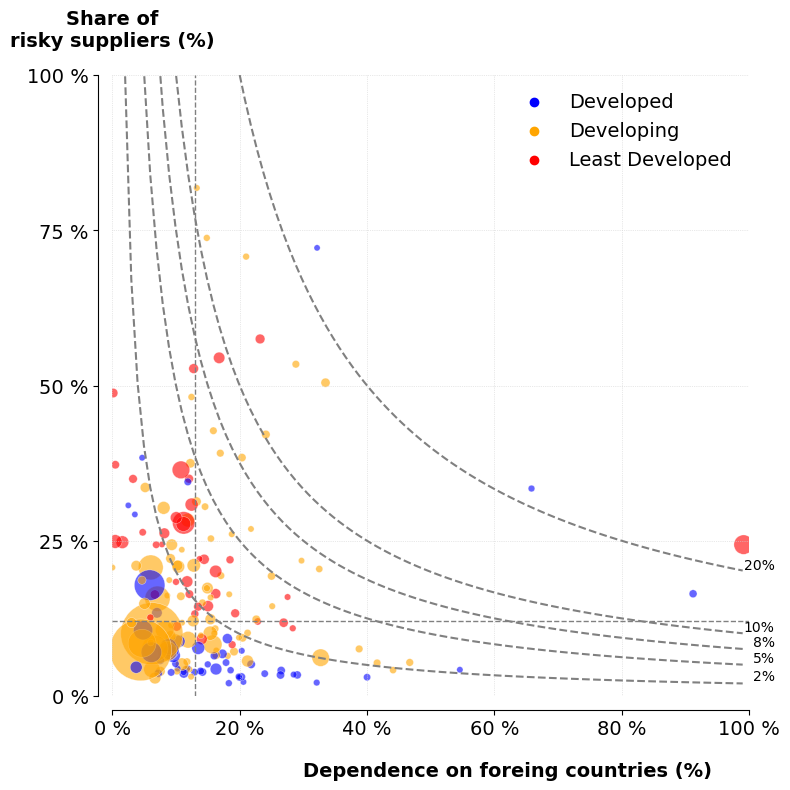

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_cons_leontief

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    # Plotting with specified order
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        hue_order=['Developed', 'Developing', 'Least Developed'],  # Controlling legend order
        palette=custom_palette,
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )


    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        frameon=False,      # Suppress the legend box
        fontsize=14
    )
    

    
median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreing countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1f.png")

plt.show()

#### Correlation

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3128478660.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


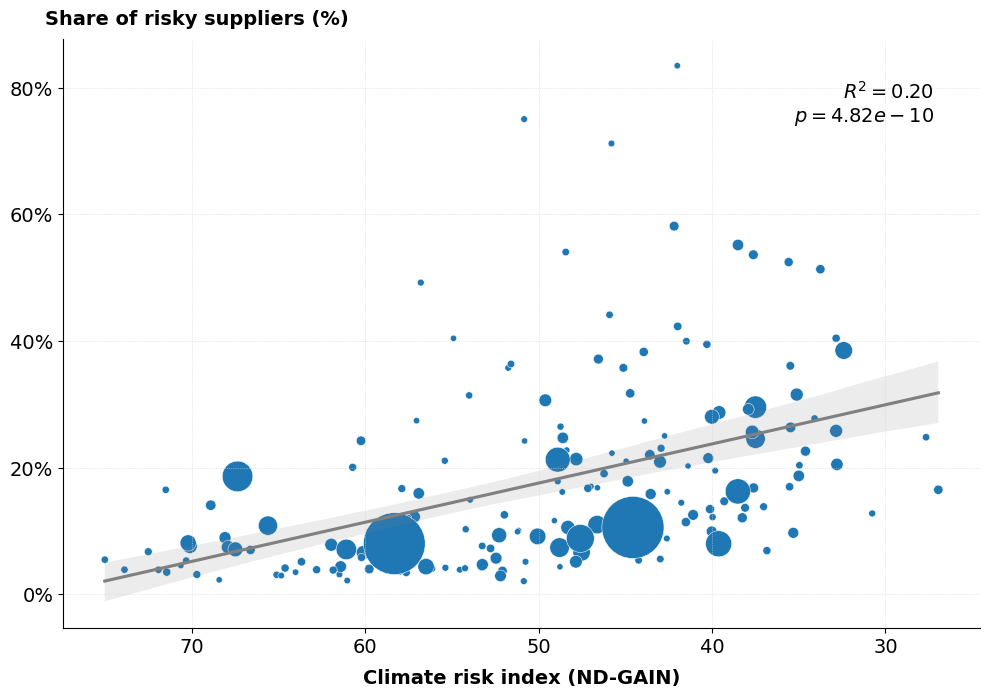

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Data setup (assuming 'result' is already your DataFrame)
result = resulting_dataframe_country_cons_leontief
result = result.dropna(subset=['Local Climate Risk'])

# Define a custom color palette
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot configuration
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x='Local Climate Risk', 
    y='Share of Risky Trade Partners (%)',
    data=result, 
    palette=custom_palette, 
    size='Population', 
    sizes=(20, 2000)
)

# Extract handles and labels for legend
handles, labels = scatter.get_legend_handles_labels()
num_regions = len(result['Country'].unique())

# Legend configuration
plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
plt.legend().set_visible(False)

# Get current axes, suppress spines, reverse x-axis
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.invert_xaxis()  # Reverses the x-axis

# Regression and R-squared calculations
x = result['Local Climate Risk']
y = result['Share of Risky Trade Partners (%)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')

# Adding text for regression details
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Additional formatting
fmt = lambda x, _: '{:.0f}%'.format(x)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')
ax.set_ylabel('')
plt.subplots_adjust(right=0.75)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.text(0.5, -0.1, 'Climate risk index (ND-GAIN)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Save and show the plot
plt.tight_layout()
plt.savefig(r"Figures\Supp Mat\C\Fig3f.png")
plt.show()

#### Quadrants

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\583279000.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\583279000.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'L

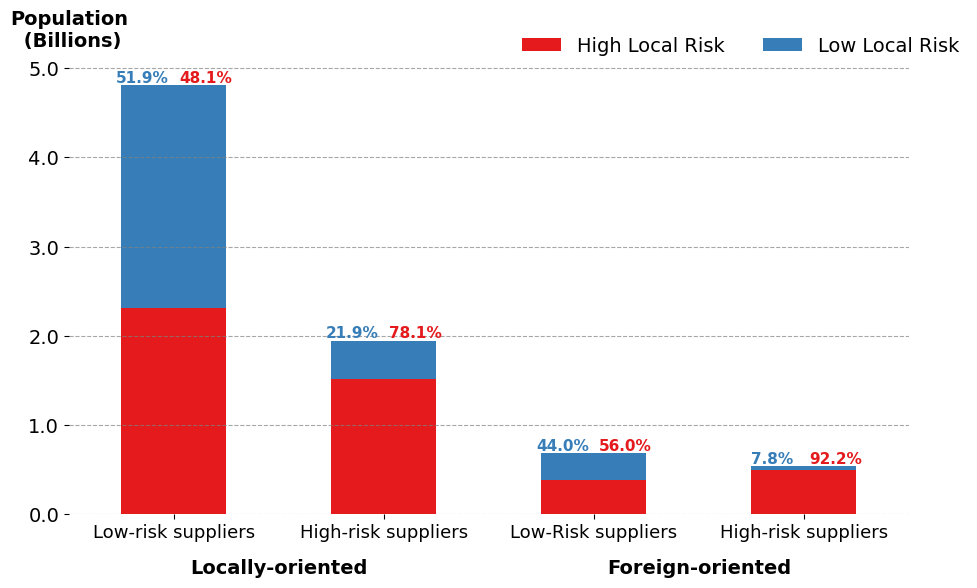

In [121]:
df = resulting_dataframe_country_cons_leontief
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5,5.2e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot

plt.savefig(r"Figures\Supp Mat\C\Fig2f.png")

plt.show()

## Exports
-----

### Leontief CI
-----

#### Code
-----

In [9]:
import pandas as pd

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cExports_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cExports_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cExports_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)

for c in country_list:
    exports_c = 0
    exports_c_low = 0
    exports_c_high = 0
    exports_c_row = 0

    y_c = y[~y.index.get_level_values('region').isin([c])]
    y_c_low = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(low_risk_countries)]
    y_c_high = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(high_risk_countries)]
    y_c_row = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(no_risk_countries)]

    x_c= x.loc[c].sum().iloc[0]

    for s in sector_list:
        L_cs = L.loc[c,s]
        
        L_cs = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]

        exports_cs = (L_cs*y_c).sum()
        exports_cs_low = (L_cs_foreign_low*y_c_low).sum()
        exports_cs_high = (L_cs_foreign_high*y_c_high).sum()
        exports_cs_row = (L_cs_foreign_row*y_c_row).sum()

        exports_c = exports_c + exports_cs
        exports_c_low = exports_c_low + exports_cs_low
        exports_c_high = exports_c_high + exports_cs_high
        exports_c_row = exports_c_row + exports_cs_row


    cExports.loc[c] = exports_c / x_c*100
    cExports_low.loc[c] = exports_c_low / x_c*100
    cExports_high.loc[c] = exports_c_high / x_c *100
    cExports_row.loc[c] = exports_c_row / x_c *100

    
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_low, cExports_high,cExports_row, cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CI = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CI.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_exports_leontief_CI = result

C:\Users\delah\AppData\Local\Temp\ipykernel_2764\1560160571.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.4430912088531453' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports.loc[c] = exports_c / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_2764\1560160571.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.8610490719747557' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_low.loc[c] = exports_c_low / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_2764\1560160571.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.565423276688109' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_high.loc[c] = exports_c_hi

In [12]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_exports_leontief_CI.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_exports_leontief_CI, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_exports_leontief_CI.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_leontief_CI = pickle.load(f)

In [170]:
resulting_dataframe_country_exports_leontief_CI

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Belarus,BLR,57.893267,Low Risk,Europe & Central Asia,Upper middle income,9167767.0,Developed,88.827644,3.652942,0,92.536338,7.463662,3.949955
1,Ethiopia,ETH,37.492203,High Risk,Sub-Saharan Africa,Low income,126527060.0,Least Developed,85.657847,4.050436,0,89.744941,10.255059,4.515119
2,Malta,MLT,58.044556,Low Risk,Middle East & North Africa,High income,524909.0,Developed,55.365391,6.267760,0,61.774144,38.225856,10.169462
3,San Marino,SMR,60.117865,Low Risk,Europe & Central Asia,High income,33642.0,Developed,49.053521,8.266020,0,57.709194,42.290806,14.420946
4,Djibouti,DJI,42.581724,High Risk,Middle East & North Africa,Lower middle income,1136455.0,Least Developed,45.445747,10.091614,0,56.070892,43.929108,18.170855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,Yemen,YEM,34.998525,High Risk,Middle East & North Africa,Low income,34449825.0,Least Developed,3.513543,0.291142,0,3.806071,96.193929,7.652186
175,Afghanistan,AFG,32.797710,High Risk,South Asia,Low income,42239854.0,Least Developed,0.874239,1.565423,0,2.443091,97.556909,64.165564
176,Sudan,SUD,32.845793,High Risk,Sub-Saharan Africa,Low income,48109006.0,Least Developed,0.976326,0.153066,0,1.141849,98.858151,13.552923
177,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.120849,0.031761,0,0.153248,99.846752,20.811717


#### XY
-----

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

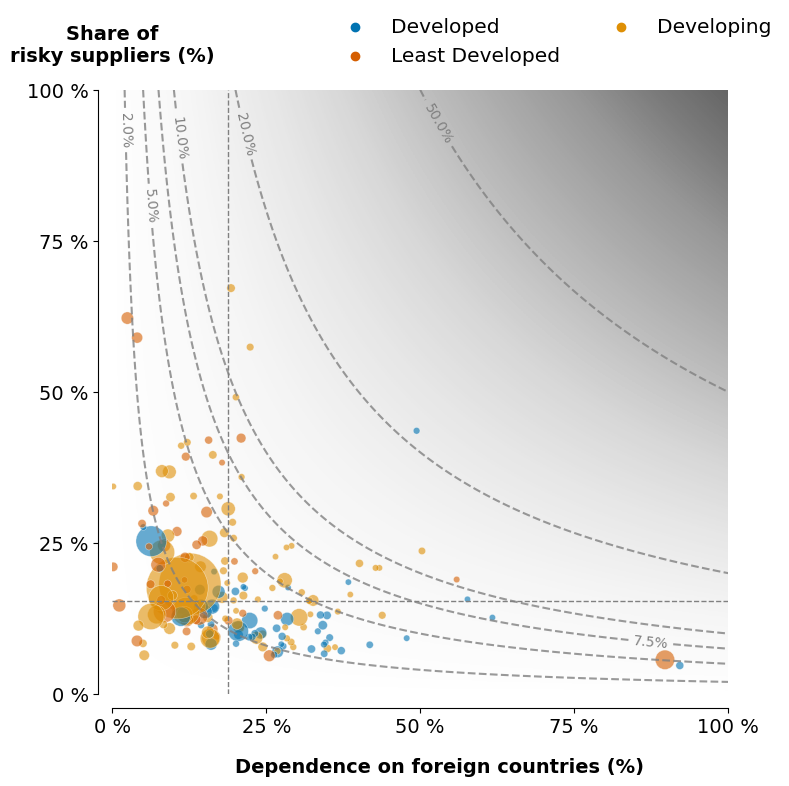

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator

result = resulting_dataframe_country_exports_leontief_CF

constants = [200, 500, 750, 1000, 2000,5000]

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))


# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 10, 256)
y = np.linspace(0, 10, 256)

z = np.outer(y,x)

plt.imshow(z, aspect='auto', extent=[0, 100, 0, 100], origin='lower', cmap='Greys',alpha=0.6)

plt.ylim(0, 100)
plt.xlim(0, 100)

# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 100, 256)
y = np.linspace(0, 100, 256)
X, Y = np.meshgrid(x, y)
Z = X * Y  # Adjust this function as needed to match the background gradient

# Create contour plot
contour = plt.contour(X, Y, Z, constants, colors='grey', linestyles='dashed', alpha=0.8)

# Label each contour line with its respective value divided by 1000
fmt = lambda x: f"{x/100:.1f}%"
clabels = plt.clabel(contour, fmt=fmt, inline=True, fontsize=10, colors='black')

# Adjust label colors to make them darker than contour lines
for label in clabels:
    label.set_color('grey')

    
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    #plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=0.3)
    # Adding text for the value of the constant
    #plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
palette = sns.color_palette(palette="colorblind", as_cmap=True)
# Colorblind-friendly palette
risk_palette = {'Developed': palette[0],  # Sky Blue
                'Developing': palette[1],
               "Least Developed":palette[3]}  # Coral

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='Share of Risky Trade Partners (%)',
        hue='Development', 
        data=result, 
        palette=risk_palette, 
        size='Population', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        bbox_to_anchor=(1.1,1.15),
        frameon=False,      # Suppress the legend box
        fontsize=14.5,
        ncol=2
    )

    
# Add letters to each quadrant
#plt.text(5, 5, 'A', fontsize=20, fontweight='bold')
#plt.text(13, 95, 'B', fontsize=20, fontweight='bold')
#plt.text(95, 14, 'C', fontsize=20, fontweight='bold')
#plt.text(95, 95, 'D', fontsize=20, fontweight='bold')

median_x = result['Foreign (%)'].median()
median_y = result['Share of Risky Trade Partners (%)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(20, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

locator = MaxNLocator(nbins=4)  # Set the number of bins to control the tick frequency
scatter.xaxis.set_major_locator(locator)
scatter.yaxis.set_major_locator(locator)
# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.tight_layout()

#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1f.png")

plt.show()

In [25]:
resulting_dataframe_country_exports_leontief_CI

,Country,Local Risk,Local Climate Risk,Region,Income group,Population (2023),Development,Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,Belarus,Low Risk,57.893267,Europe & Central Asia,Upper middle income,9167767,Developed,92.536338,7.463662,0.925363,0.925363,50.0
1,Ethiopia,High Risk,37.492203,Sub-Saharan Africa,Low income,126527060,Least Developed,89.744941,10.255059,0.897449,0.897449,50.0
2,Malta,Low Risk,58.044556,Middle East & North Africa,High income,524909,Developed,61.774144,38.225856,0.617741,0.617741,50.0
3,San Marino,Low Risk,60.117865,Europe & Central Asia,High income,33642,Developed,57.709194,42.290806,0.577092,0.577092,50.0
4,Djibouti,High Risk,42.581724,Middle East & North Africa,Lower middle income,1136455,Least Developed,56.070892,43.929108,0.560709,0.560709,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...
174,"Yemen, Rep.",High Risk,34.998525,Middle East & North Africa,Low income,34449825,Least Developed,3.806071,96.193929,0.038061,0.038061,50.0
175,Afghanistan,High Risk,32.797710,South Asia,Low income,42239854,Least Developed,2.443091,97.556909,0.024431,0.024431,50.0
176,Sudan,High Risk,32.845793,Sub-Saharan Africa,Low income,45700000,Least Developed,1.141849,98.858151,0.011418,0.011418,50.0
177,Somalia,High Risk,33.752517,Sub-Saharan Africa,Low income,18143378,Least Developed,0.153248,99.846752,0.001532,0.001532,50.0


#### Correlation

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\2444874886.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


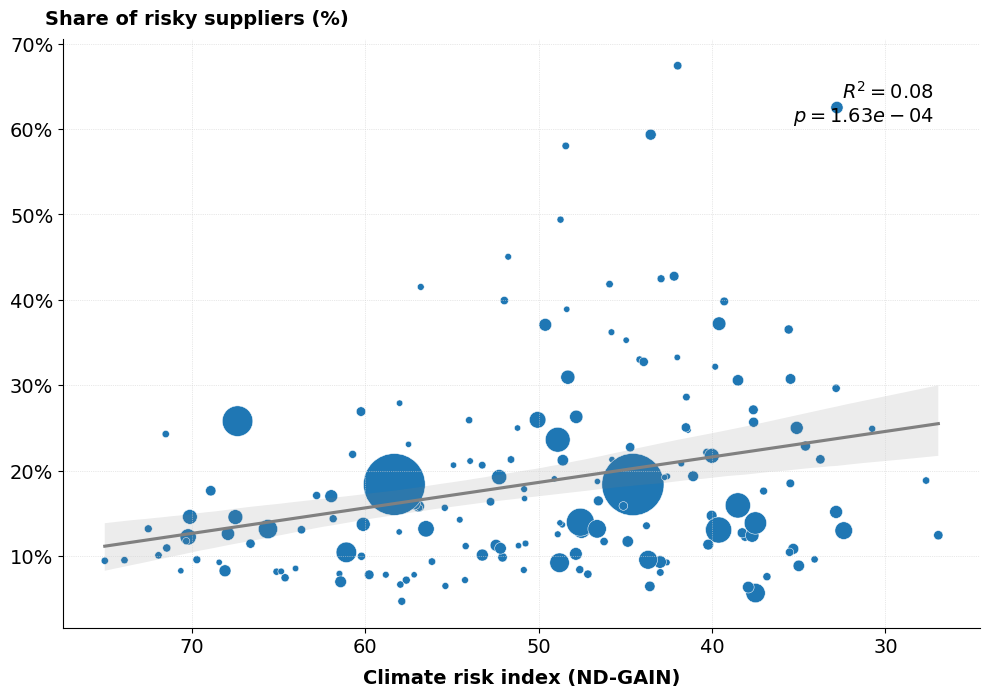

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Data setup (assuming 'result' is already your DataFrame)
result = resulting_dataframe_country_exports_leontief_CF
result = result.dropna(subset=['Local Climate Risk'])

# Define a custom color palette
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot configuration
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x='Local Climate Risk', 
    y='Share of Risky Trade Partners (%)',
    data=result, 
    palette=custom_palette, 
    size='Population', 
    sizes=(20, 2000)
)

# Extract handles and labels for legend
handles, labels = scatter.get_legend_handles_labels()
num_regions = len(result['Country'].unique())

# Legend configuration
plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
plt.legend().set_visible(False)

# Get current axes, suppress spines, reverse x-axis
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.invert_xaxis()  # Reverses the x-axis

# Regression and R-squared calculations
x = result['Local Climate Risk']
y = result['Share of Risky Trade Partners (%)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')

# Adding text for regression details
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Additional formatting
fmt = lambda x, _: '{:.0f}%'.format(x)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')
ax.set_ylabel('')
plt.subplots_adjust(right=0.75)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.text(0.5, -0.1, 'Climate risk index (ND-GAIN)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Save and show the plot
plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig3g.png") # CI
plt.savefig(r"Figures\Supp Mat\C\Fig3h.png") # CF
plt.show()

#### Quadrants

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3630460209.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3630460209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 

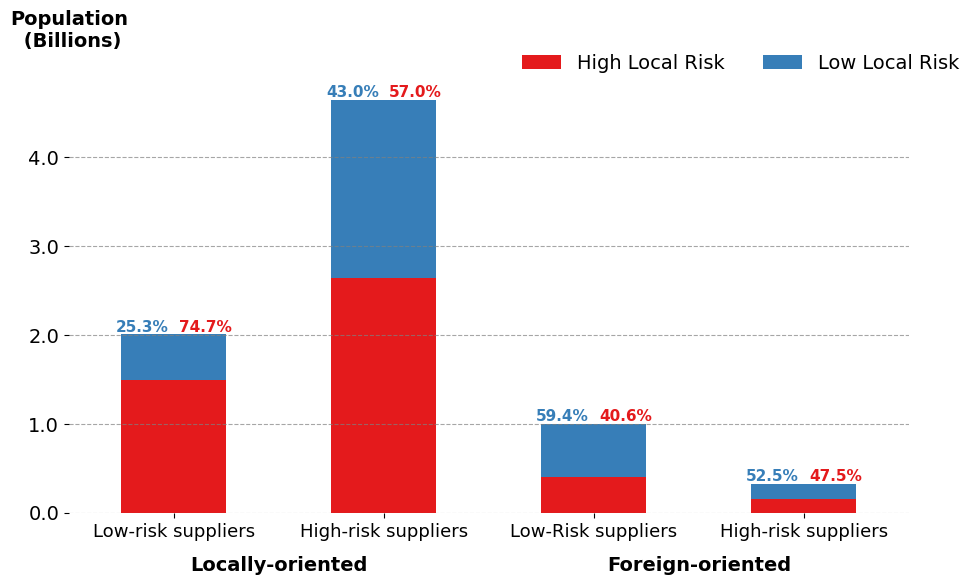

In [127]:
df = resulting_dataframe_country_exports_leontief_CF
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5,5.2e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot

# Show the plot
#plt.savefig(r"Figures\Supp Mat\C\Fig2g.png") #CI
plt.savefig(r"Figures\Supp Mat\C\Fig2h.png") #CF

plt.show()

### Leontief CF

#### Code

In [84]:
import pandas as pd

final_production = mriot.Y.copy()

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

Y = mriot.Y.copy()
# Group by the first level ('region') and sum values along columns for each 'region'
final_production_by_destination = Y.groupby(level='region', axis=1).sum()

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

values = {'ROW': [0] * multi_index.size}
risk_cs_row = pd.DataFrame(values, index=multi_index)

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            final_production_cs=final_production_by_destination.loc[c,s]
            final_production_cs_tot = final_production_cs.sum()
            if final_production_cs_tot>0:
                risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
                risk_cs_high.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(high_risk_countries)].sum() / final_production_cs_tot*100
                risk_cs_row.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(no_risk_countries)].sum() / final_production_cs_tot*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high,risk_cs_row]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\140244954.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\140244954.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '99.01179421174416' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\140244954.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.8625432741786007' has dtype incompatible with int64, please explicitly cast to a compatible dtype

In [87]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_exports_leontief.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [24]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_exports_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [88]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cExports_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cExports_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cExports_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)


for c in country_list:
    exports_c = 0
    exports_c_low = 0
    exports_c_high = 0
    exports_c_row = 0

    final_production = y
    final_production_and_risk_c_low = y*risk_cs.loc[c]['Low Risk']/100
    final_production_and_risk_c_high = y*risk_cs.loc[c]['High Risk']/100
    final_production_and_risk_c_row = y*risk_cs.loc[c]['ROW']/100

    for s in sector_list:
        L_cs = L.loc[c,s]
        
        exports_cs= (L_cs*final_production).sum()
        exports_cs_low = (L_cs*final_production_and_risk_c_low).sum()
        exports_cs_high = (L_cs*final_production_and_risk_c_high).sum()
        exports_cs_row = (L_cs*final_production_and_risk_c_row).sum()

        exports_c = exports_c + exports_cs
        exports_c_low = exports_c_low + exports_cs_low  
        exports_c_high = exports_c_high + exports_cs_high  
        exports_c_row = exports_c_row + exports_cs_row 


    x_c = x.loc[c].sum().iloc[0]

    cExports_low.loc[c] = exports_c_low / x_c*100
    cExports_high.loc[c] = exports_c_high / x_c *100
    cExports_row.loc[c] = exports_c_row / x_c *100
    
    cExports.loc[c] = cExports_low.loc[c].iloc[0]+cExports_high.loc[c].iloc[0]+cExports_row.loc[c].iloc[0]

    cLocal_Use.loc[c] = 100 - cExports_low.loc[c].iloc[0]- cExports_high.loc[c].iloc[0]- cExports_row.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_low, cExports_high,cExports_row,cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CF = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CF.sort_values('Foreign (%)', ascending=False).reset_index()


# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_exports_leontief_CF = result

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\4140843009.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.9109194193874743' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_low.loc[c] = exports_c_low / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\4140843009.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.5192798224645347' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_high.loc[c] = exports_c_high / x_c *100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\4140843009.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.014994761334623458' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_row.loc[c

In [90]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_exports_leontief_CF.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_exports_leontief_CF, f)

In [216]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_exports_leontief_CF.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_leontief_CF = pickle.load(f)

## Correlation between imports and exports

In [18]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_exports_leontief_CI.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_leontief_CI = pickle.load(f)

In [19]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_inputs_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_inputs_leontief = pickle.load(f)

In [20]:
df1=resulting_dataframe_country_inputs_leontief
df2= resulting_dataframe_country_exports_leontief_CI
result_df = pd.merge(df1, df2, 
                     on=['Country', 'Country Code', 'Local Climate Risk', 'Local Risk', 'Region', 'Income group', 'Population', 'Development'], 
                     how='left',
                     suffixes=('_imports', '_exports'))

result_df

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%)_imports,High Risk Exposure (%)_imports,ROW_imports,Foreign (%)_imports,Local (%)_imports,Share of Risky Trade Partners (%)_imports,Low Risk Exposure (%)_exports,High Risk Exposure (%)_exports,ROW_exports,Foreign (%)_exports,Local (%)_exports,Share of Risky Trade Partners (%)_exports
0,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,37.233610,15.576317,5.706165,58.516092,41.483908,29.495055,25.532883,21.683864,2.611080,49.827827,50.172173,45.924096
1,"China, Hong Kong SAR",HKG,NaN,Unknown,East Asia & Pacific,High income,7350409.0,Developing,52.654622,2.770289,1.929616,57.354527,42.645473,4.998273,37.977164,5.640892,0.492843,44.110900,55.889100,12.932470
2,San Marino,SMR,NaN,Unknown,Europe & Central Asia,High income,33642.0,Developed,24.079857,19.126293,7.800318,51.006468,48.993532,44.267525,47.590117,8.266020,1.853057,57.709194,42.290806,14.798768
3,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,40.318116,5.668660,2.124597,48.111373,51.888627,12.326718,35.765728,12.281789,2.305061,50.352579,49.647421,25.561756
4,Luxembourg,LUX,68.424627,Low Risk,Europe & Central Asia,High income,657569.0,Developed,45.154157,1.469545,0.250341,46.874044,53.125956,3.151927,44.314444,3.173027,0.390927,47.878398,52.121602,6.681819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,1.040105,0.550403,0.123794,1.714303,98.285697,34.605484,0.118362,0.031761,0.003125,0.153248,99.846752,21.156419
183,South Sudan,SDS,32.845793,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.968992,0.413513,0.145162,1.527666,98.472334,29.910400,3.162939,1.346533,0.398436,4.907907,95.092093,29.860101
184,Guyana,GUY,44.952938,High Risk,Latin America & Caribbean,High income,813834.0,Developing,0.891494,0.324433,0.009092,1.225018,98.774982,26.681940,0.093444,0.052768,0.006538,0.152750,99.847250,36.089915
185,Myanmar,MMR,37.686660,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.602205,0.184094,0.038447,0.824747,99.175253,23.412739,9.251242,1.259434,0.207315,10.717990,89.282010,11.982424


C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

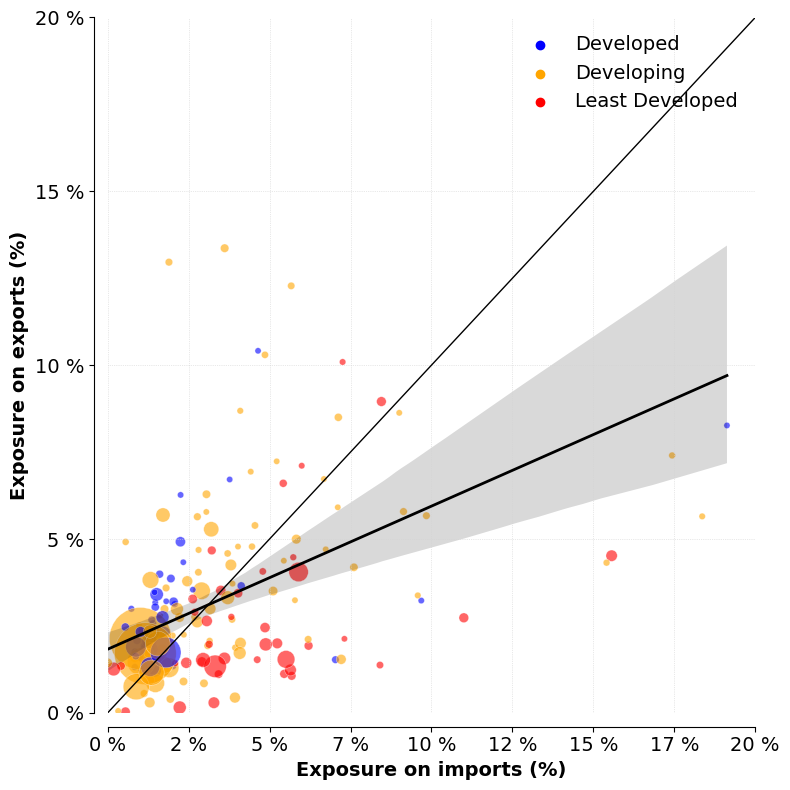

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = result_df

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 20)
plt.xlim(0, 20)

# Define custom palette for scatter plot based on development status
custom_palette = {'Developed': 'blue', 'Least Developed': 'red', 'Developing': 'orange'}

# Scatter plot configuration
scatter = sns.scatterplot(
    x='High Risk Exposure (%)_imports',
    y='High Risk Exposure (%)_exports',
    hue='Development', 
    data=result, 
    palette=custom_palette, 
    size='Population', 
    sizes=(20, 2000),
    alpha=0.6
)

# Add a single regression line for the entire dataset without confidence intervals
sns.regplot(
    x='High Risk Exposure (%)_imports',
    y='High Risk Exposure (%)_exports',
    data=result,
    scatter=False,  # Only plot the regression line, no scatter points from regplot
    color='black',  # Set the color of the regression line to black
    line_kws={'linewidth': 2, 'linestyle': '-'},  # Customize line appearance
    ax=plt.gca()  # Ensure the regression line is added to the existing plot
)

# Adjusting legend and axes
handles, labels = scatter.get_legend_handles_labels()
num_developed_groups = len(result['Development'].unique())
plt.legend(
    handles=handles[1:num_developed_groups+1], 
    labels=labels[1:num_developed_groups+1], 
    loc='upper right', 
    frameon=False, 
    fontsize=14
)

# Add the y = x line in black
plt.plot([0, 20], [0, 20], color='black', linewidth=1)

# Spine and label adjustments
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

plt.ylabel('Exposure on exports (%)', fontsize=14, weight='bold')
plt.xlabel('Exposure on imports (%)', fontsize=14, weight='bold')

# Set major locators for the y-axis
scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

# Format the axis labels as percentages
def percentage_formatter(x, pos):
    return f'{int(x)} %'
x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Font size adjustments for axis tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add grid
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
plt.tight_layout()

# Display the plot
plt.show()

<Figure size 800x600 with 0 Axes>

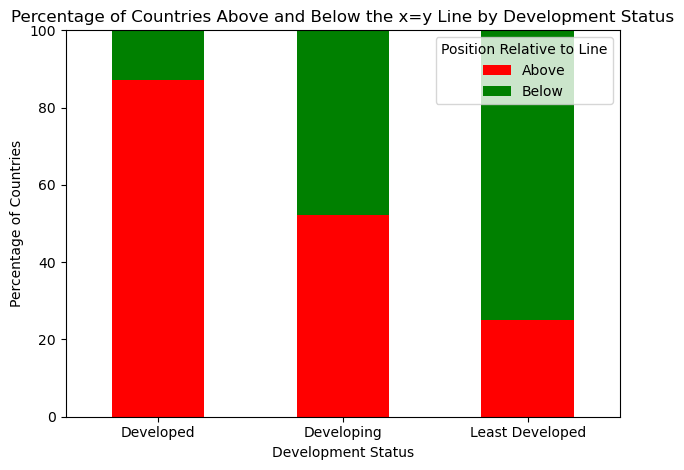

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

result = result_df

# Determine the position relative to the y = x line
result['Position'] = np.where(result['High Risk Exposure (%)_exports'] > result['High Risk Exposure (%)_imports'], 'Above', 'Below')

# Count the number of points above and below the line for each development category
position_counts = result.groupby(['Development', 'Position']).size().unstack(fill_value=0)

# Normalize the counts to convert them to percentages
position_percentages = position_counts.div(position_counts.sum(axis=1), axis=0) * 100

# Plotting
plt.figure(figsize=(8, 6))
position_percentages.plot(kind='bar', stacked=True, color=['red', 'green'])  # Red for below, green for above
plt.title('Percentage of Countries Above and Below the x=y Line by Development Status')
plt.xlabel('Development Status')
plt.ylabel('Percentage of Countries')
plt.xticks(rotation=0)  # Keep the category names horizontal for better readability
plt.legend(title='Position Relative to Line', labels=['Above', 'Below'])
plt.ylim(0, 100)  # Set y-axis limit to 100% for clarity
plt.tight_layout()

# Show the plot
plt.show()

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

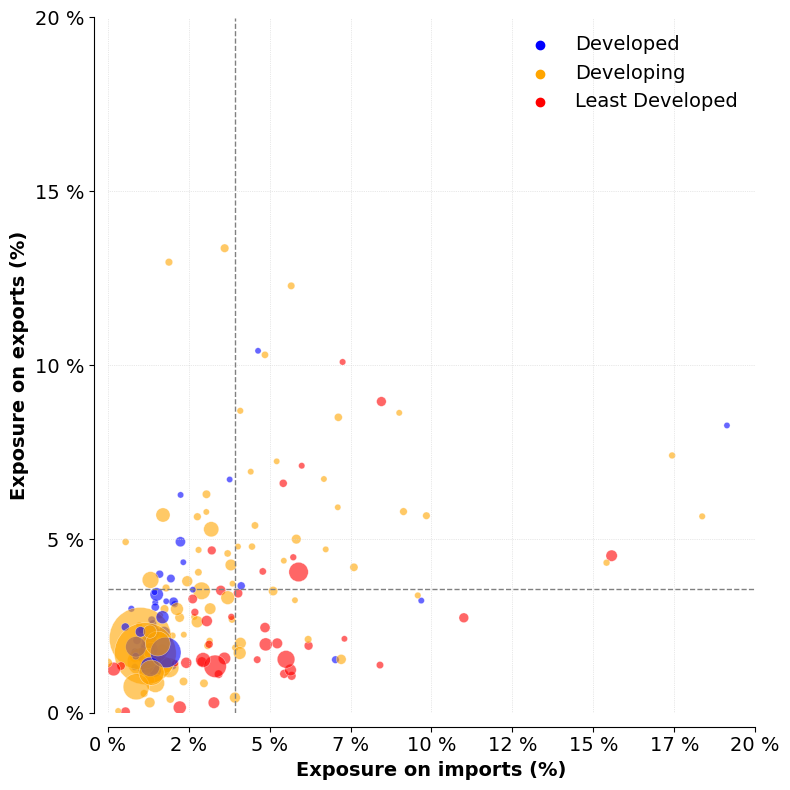

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = result_df

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 20)
plt.xlim(0, 20)

# Define custom palette for scatter plot based on development status
custom_palette = {'Developed': 'blue', 'Least Developed': 'red', 'Developing': 'orange'}

# Scatter plot configuration
scatter = sns.scatterplot(
    x='High Risk Exposure (%)_imports',
    y='High Risk Exposure (%)_exports',
    hue='Development', 
    data=result, 
    palette=custom_palette, 
    size='Population', 
    sizes=(20, 2000),
    alpha=0.6
)

# Calculate medians of the x and y data
threshold_imports = result['High Risk Exposure (%)_imports'].quantile(0.70)
threshold_exports = result['High Risk Exposure (%)_exports'].quantile(0.70)

# Add median lines to split the graph into four quadrants
plt.axvline(x=threshold_imports, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=threshold_exports, color='gray', linestyle='--', linewidth=1)

# Adjusting legend and axes
handles, labels = scatter.get_legend_handles_labels()
num_developed_groups = len(result['Development'].unique())
plt.legend(
    handles=handles[1:num_developed_groups+1], 
    labels=labels[1:num_developed_groups+1], 
    loc='upper right', 
    frameon=False, 
    fontsize=14
)

# Spine and label adjustments
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

plt.ylabel('Exposure on exports (%)', fontsize=14, weight='bold')
plt.xlabel('Exposure on imports (%)', fontsize=14, weight='bold')

# Set major locators for the y-axis
scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

# Format the axis labels as percentages
def percentage_formatter(x, pos):
    return f'{int(x)} %'
x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Font size adjustments for axis tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add grid
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
plt.tight_layout()

# Display the plot
plt.show()

C:\Users\delah\AppData\Local\Temp\ipykernel_2764\2790701065.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Imports Category'] = df['High Risk Exposure (%)_imports'].apply(lambda x: 'High Risk Imports' if x > threshold_imports else 'Low Risk Imports')
C:\Users\delah\AppData\Local\Temp\ipykernel_2764\2790701065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Exports Category'] = df['High Risk Exposure (%)_exports'].apply(lambda x: 'High Risk Exports' if x > threshold_exports else 'Low Risk 

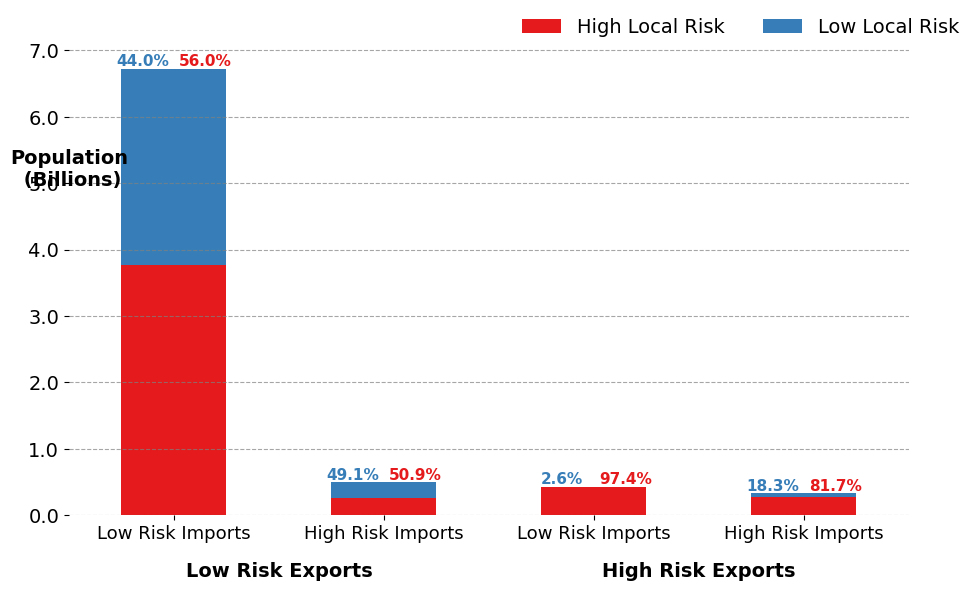

In [30]:
df=result_df
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
q=0.7
threshold_imports = df['High Risk Exposure (%)_imports'].quantile(q)
threshold_exports = df['High Risk Exposure (%)_exports'].quantile(q)

# Add columns to indicate if each row is over or under the median for the specified columns
df['Imports Category'] = df['High Risk Exposure (%)_imports'].apply(lambda x: 'High Risk Imports' if x > threshold_imports else 'Low Risk Imports')
df['Exports Category'] = df['High Risk Exposure (%)_exports'].apply(lambda x: 'High Risk Exports' if x > threshold_exports else 'Low Risk Exports')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['High Risk Exposure (%)_imports', 'High Risk Exposure (%)_exports'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Imports Category', 'Exports Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Low Risk Imports', 'Low Risk Exports'),
    ('Low Risk Imports', 'High Risk Exports'),
    ('High Risk Imports', 'Low Risk Exports'),
    ('High Risk Imports', 'High Risk Exports'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.9e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low Risk Imports', 'High Risk Imports', 'Low Risk Imports', 'High Risk Imports']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Low Risk Exports","High Risk Exports"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()


plt.show()

# Sector-level analysis
-----

## Inputs
----

Backward exposure of the whole economy of c on good s as intermediary consumption

In [91]:
import pandas as pd    

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

index_cs = mriot.x.index

values = {'Low Risk': [0] * index_cs.size}
Foreign_Inputs_low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
Foreign_Inputs_high = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
Foreign_Inputs_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Inputs = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Inputs = pd.DataFrame(values, index=index_cs)


for s in sector_list:    
    for c in country_list:
        L_c = L[c]
        y_c = y[c]
        
        inputs_cs = L_c.groupby('sector').sum().loc[s].dot(y_c)  # products s used as inputs for all sectors of c's economy
        
        if inputs_cs != 0 :
            Foreign_Inputs.loc[c,s]= L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Local_Inputs.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_low.loc[c,s] =  L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(low_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_high.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(high_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_ROW.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(no_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100

# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Inputs_low, Foreign_Inputs_high, Foreign_Inputs_ROW,Foreign_Inputs, Local_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_sectors_inputs_leontief=result

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3377223319.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '91.65987889887018' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Inputs.loc[c,s]= L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3377223319.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '8.340121101129828' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Local_Inputs.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\3377223319.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and wil

Number of outliers: 180
Outlier values: [11.084886274137292, 12.114431423393942, 13.375462876807683, 12.971528692944506, 14.121468753948491, 11.360749817914023, 18.176754981761086, 11.219974682649628, 15.085910155828294, 13.141476841503701, 16.285746129547995, 13.44598143326701, 12.554866425646328, 13.02908107427146, 17.359866606124967, 15.634720845380818, 11.674405397808712, 11.548281514909299, 19.587813465203098, 23.054982554977418, 12.76968793009062, 11.652275922881621, 17.908726036920175, 17.253871155906037, 16.426117521771086, 18.79021145845208, 14.200748326811214, 20.012746280486528, 10.98313336803524, 20.086347694123972, 21.996749637792174, 27.78928518402858, 17.61415086505951, 14.958596827440509, 25.005360729580723, 12.239654846330335, 13.357666195525885, 14.229079130702083, 14.056641094922204, 25.131990888183946, 16.557781222401253, 11.266705617972658, 25.723820777453664, 16.221186710555138, 17.576592631013334, 15.737823739699294, 15.962396569579647, 15.512474016097139, 18.869

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


NameError: name 'median_high_risk_developed_inputs' is not defined

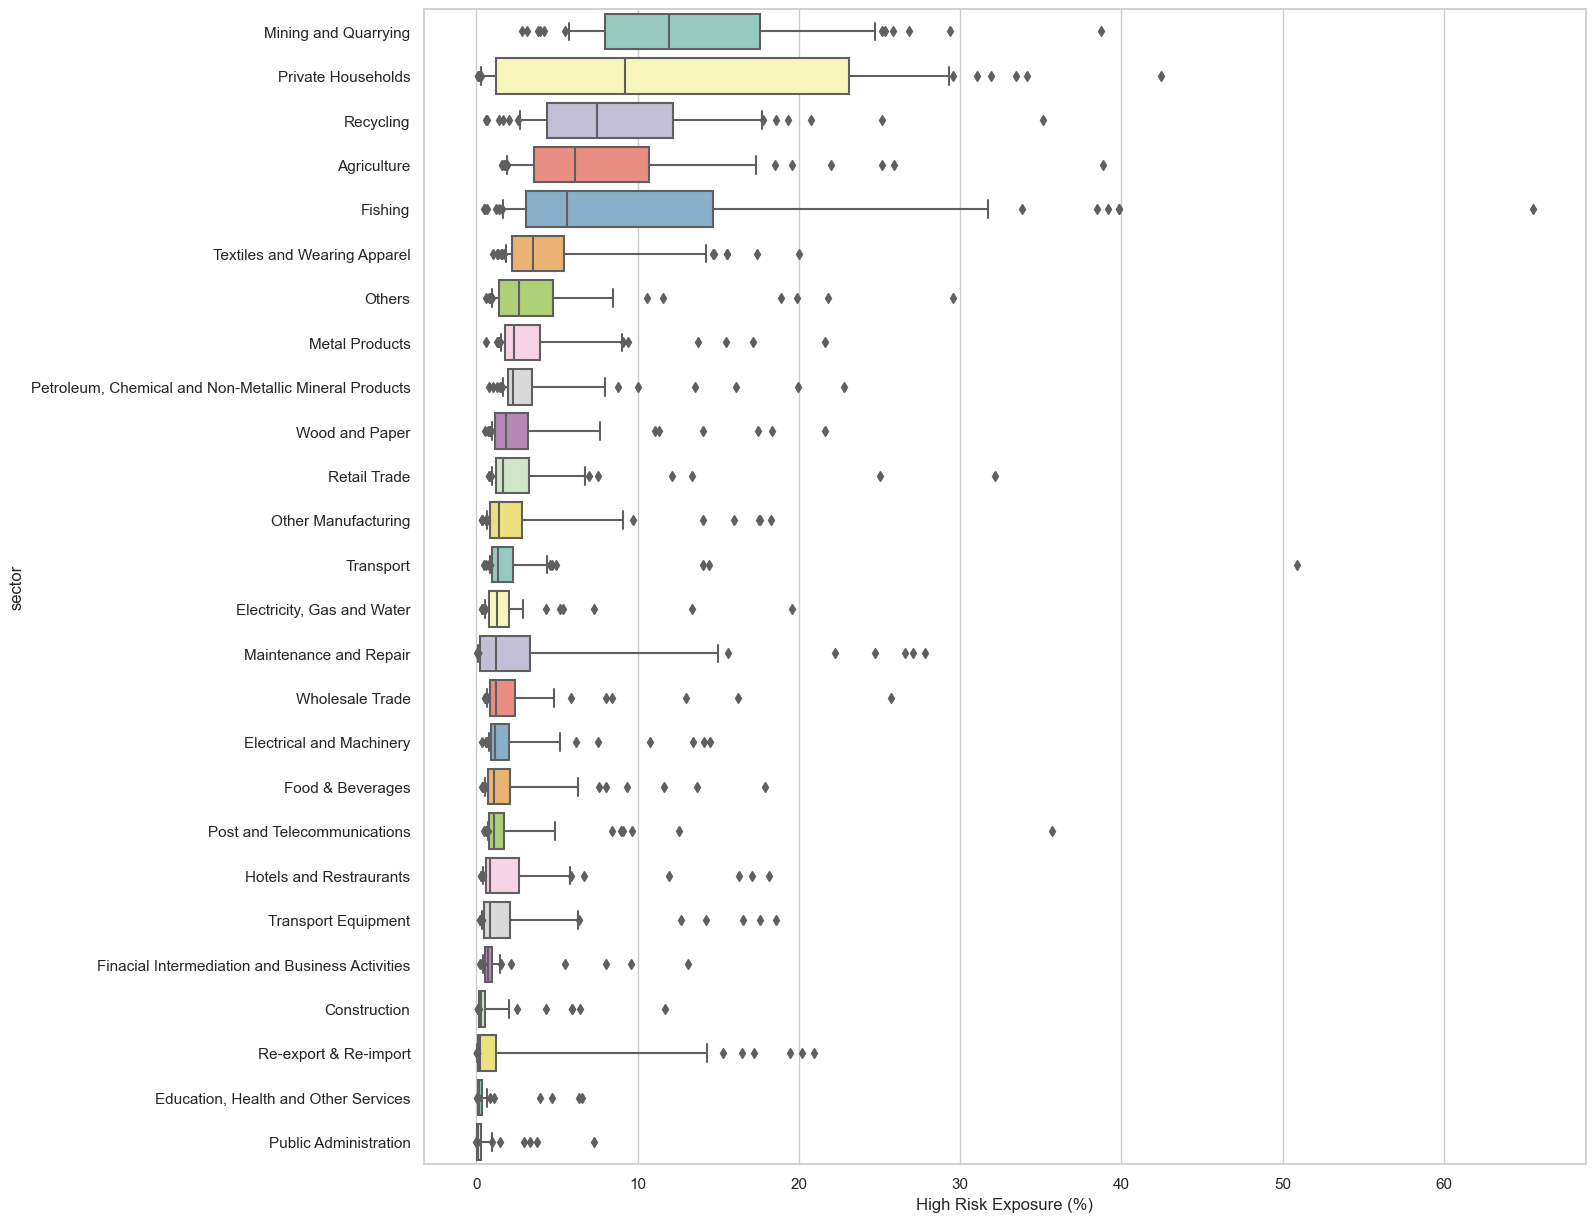

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_inputs_leontief

# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_developed[(df_developed['High Risk Exposure (%)'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk Exposure (%)'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", len(outliers))
print("Outlier values:", outliers['High Risk Exposure (%)'].tolist())

# Calculate the median 'High Risk Exposure (%)' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_inputs, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for intermediate consumption, by sector, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
plt.show()

## Consumption

In [40]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'ND_GAIN/results/risk_cs_consumption_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [41]:
index_cs = L.index

L = mriot.L

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'Household final consumption P.3h',
]

# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()

ConsoFin = final_production_by_destination_cons[c]
ConsoFin_tot=ConsoFin.groupby('sector').sum()

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * index_cs.size}
ConsoFin_Low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
ConsoFin_High = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
ConsoFin_row = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
ConsoFin_Foreign = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
ConsoFin_Local = pd.DataFrame(values, index=index_cs)

for c in country_list:
    ConsoFin = final_production_by_destination_cons[c]
    ConsoFin_tot=ConsoFin.groupby('sector').sum()
    country_list_except = [x for x in country_list if x != c]
    for s in sector_list:
        if ConsoFin_tot.loc[s]>0:
            for cc in country_list:
                ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
                ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'High Risk']/100
                ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'ROW']/100

            ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s] / ConsoFin_tot.loc[s]*100

            ConsoFin_Foreign.loc[c,s] = ConsoFin_Low.loc[c,s].iloc[0] + ConsoFin_High.loc[c,s].iloc[0]+ConsoFin_row.loc[c,s].iloc[0]
            ConsoFin_Local.loc[c,s] = 100 - ConsoFin_Foreign.loc[c,s].iloc[0]
            
# List of DataFrames to concatenate
dataframes_to_concat = [ConsoFin_Low, ConsoFin_High, ConsoFin_row, ConsoFin_Foreign, ConsoFin_Local]

resulting_dataframe_sectors_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

result = resulting_dataframe_sectors_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])


resulting_dataframe_sectors_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_12772\2580502215.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_12772\2580502215.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '74.27393099674066' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_12772\2580502215.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.06110501056783544' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c

In [43]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_sectors_cons_leontief_eora_ndgain.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_sectors_cons_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_sectors_cons_leontief_eora_ndgain.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_cons_leontief = pickle.load(f)

## Concentration

### Code

Inputs

In [44]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_inputs = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

for c in country_list:
    for s in sector_list:
        L_c=L[c]
        y_c=y[c]
        L_c=L_c.loc[~L.index.get_level_values('region').isin([c])]
        total_inputs_ext_s_to_c = L_c.groupby('sector').sum().loc[s].dot(y_c)
        hhi=0
        country_list_except_c = [item for item in country_list if item != c]
        for c0 in country_list_except_c:
            share_c0 = L_c.loc[c0,s].dot(y_c)/total_inputs_ext_s_to_c
            hhi = hhi + share_c0**2
        hhi_inputs.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_12772\4238024521.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.04639235694411205' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_inputs.loc[c,s]=hhi


Inputs among risky

Final consumption

In [47]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_cons = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'Household final consumption P.3h',
    'Non-profit institutions serving households P.3n',
    'Government final consumption P.3g','Gross fixed capital formation P.51','Acquisitions less disposals of valuables P.53'
]

# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

Y = Y.groupby(level='region', axis=1).sum()

for c in country_list:
    for s in sector_list:
        Y_c =Y[c]
        total_cons_ext_s_to_c = Y_c.loc[~Y_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s]
        hhi=0
        country_list_except_c = [item for item in country_list if item != c]
        for c0 in country_list_except_c:
            share_c0 = Y_c.loc[c0,s]/total_cons_ext_s_to_c
            hhi = hhi + share_c0**2
        hhi_cons.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_12772\2809446181.py:21: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_12772\2809446181.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.07513740051598113' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_cons.loc[c,s]=hhi


### Plot

In [74]:
df1=resulting_dataframe_sectors_cons_leontief
df2=hhi_cons
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df=result

In [72]:
df1=resulting_dataframe_sectors_inputs_leontief_2
df2=hhi_inputs
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df=result

C:\Users\delah\AppData\Local\Temp\ipykernel_12772\1289871464.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)


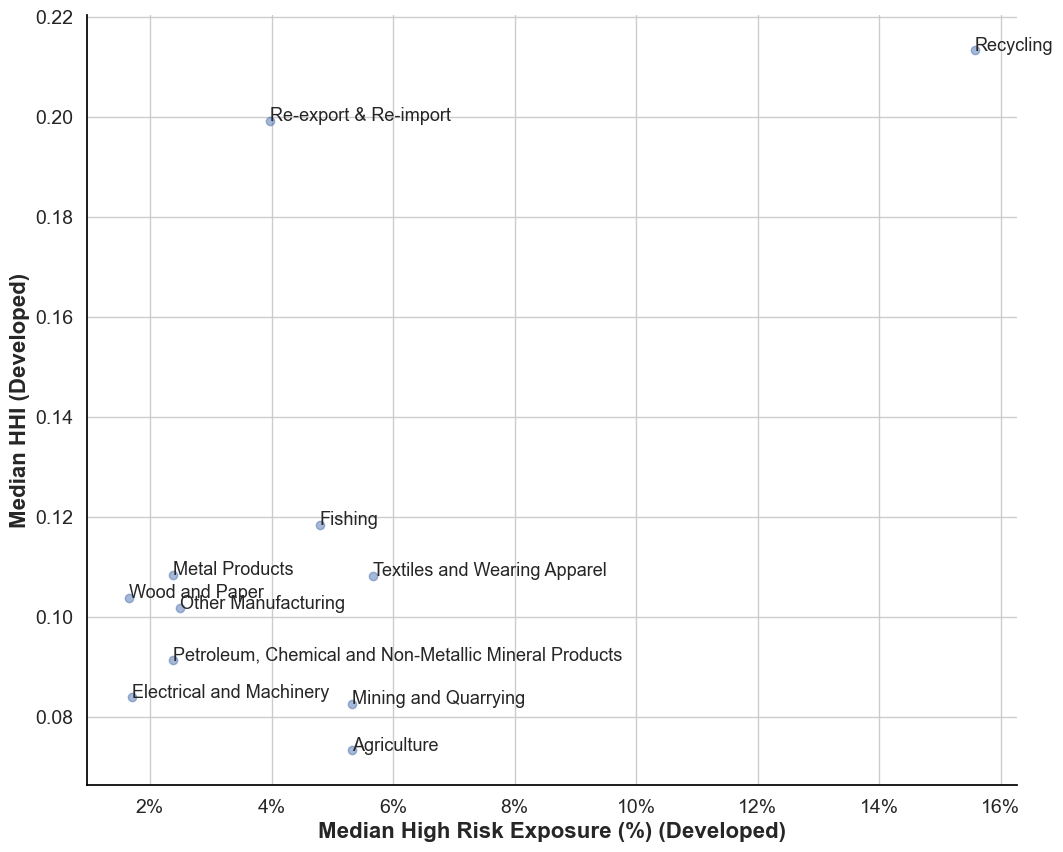

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is already in a DataFrame named 'df'
# Filter the DataFrame to only include rows where Development is 'Developed'
developed_df = df[df['Development'] == 'Developed']

# Group by 'sector' and calculate median values specifically for numeric columns
sector_medians = developed_df.groupby('sector').median(numeric_only=True)[['High Risk Exposure (%)', 'HHI']]

# Filter out sectors where the median High Risk Exposure (%) is less than 2%
#filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed_consumption]
filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed_inputs]

# Plotting
plt.figure(figsize=(12, 10))
ax = plt.gca()  # Get current axis

# Removing top and right borders and setting the bottom and left spines black
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Scatter plot without the incorrect 'fontsize' parameter
plt.scatter(filtered_sector_medians['High Risk Exposure (%)'], filtered_sector_medians['HHI'], alpha=0.5)

# Setting labels with font size and weight adjustments
plt.xlabel('Median High Risk Exposure (%) (Developed)', fontsize=16, fontweight='bold')
plt.ylabel('Median HHI (Developed)', fontsize=16, fontweight='bold')

# Formatting the x-axis labels as percentages and setting label sizes
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Setting grid
plt.grid(True)

# Adding sector labels to the points
for i, txt in enumerate(filtered_sector_medians.index):
    plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)

plt.show()

# Sensitivity Analysis

## Threshold function

In [93]:
import pandas as pd

def create_local_climate_risk(climate_risk, t):
    df=climate_risk.copy()
    
    df['Local Risk'] = pd.cut(df['Local Climate Risk'], bins=[0, t, 100], labels=['High Risk', 'Low Risk'], right=True)

    modified_local_climate_risk=df
    return modified_local_climate_risk


# Call the function with simulated data and thresholds
modified_local_climate_risk = create_local_climate_risk(local_climate_risk, 50)

In [94]:
df=modified_local_climate_risk
L= mriot.L
country_list = L.index.get_level_values(0).unique()

low_risk_countries = list(df[df['Local Risk']=='Low Risk']['Country Code'])
high_risk_countries = list(df[df['Local Risk']=='High Risk']['Country Code'])

low_risk_countries = list(set(low_risk_countries) & set(country_list))
high_risk_countries = list(set(high_risk_countries) & set(country_list))

len(low_risk_countries)+len(high_risk_countries)

172

Generate exposure calculation

In [95]:
import pandas as pd

def calculate_country_inputs(modified_local_climate_risk, mriot):
    Y = mriot.Y
    y = Y.sum(axis = 1)

    L= mriot.L
    country_list = L.index.get_level_values(0).unique()
    sector_list = L.index.get_level_values(1).unique()

    df=modified_local_climate_risk

    modified_low_risk_countries = list(df[df['Local Risk']=='Low Risk']['Country Code'])
    modified_high_risk_countries = list(df[df['Local Risk']=='High Risk']['Country Code'])

    #modified_low_risk_countries = list(set(modified_low_risk_countries) & set(country_list))
    #modified_high_risk_countries = list(set(modified_high_risk_countries) & set(country_list))
    
    values = {'Low Risk': [0] * country_list.size}
    cForeign_Inputs_low = pd.DataFrame(values, index=country_list)

    values = {'High Risk': [0] * country_list.size}
    cForeign_Inputs_high = pd.DataFrame(values, index=country_list)

    values = {'ROW': [0] * country_list.size}
    cForeign_Inputs_row = pd.DataFrame(values, index=country_list)

    values = {'Foreign (%)': [0] * country_list.size}
    cForeign_Inputs = pd.DataFrame(values, index=country_list)

    values = {'Local (%)': [0] * country_list.size}
    cLocal_Inputs = pd.DataFrame(values, index=country_list)


    for c in country_list:
        intrants_c = 0
        intrants_c_foreign = 0
        intrants_c_foreign_low = 0
        intrants_c_foreign_high = 0
        intrants_c_foreign_row = 0


        for s in sector_list:
            L_cs = L[c,s]
            y_cs = y[c,s]
            L_cs_foreign = L_cs[L_cs.index.get_level_values('region') != c]
            L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(modified_low_risk_countries)]
            L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(modified_high_risk_countries)]
            L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]

            intrants_cs = (L_cs*y_cs).sum()
            intrants_cs_foreign = (L_cs_foreign*y_cs).sum()
            intrants_cs_foreign_low = (L_cs_foreign_low*y_cs).sum()
            intrants_cs_foreign_high = (L_cs_foreign_high*y_cs).sum()
            intrants_cs_foreign_row = (L_cs_foreign_row*y_cs).sum()

            intrants_c=intrants_c + intrants_cs
            intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
            intrants_c_foreign_low = intrants_c_foreign_low + intrants_cs_foreign_low 
            intrants_c_foreign_high = intrants_c_foreign_high + intrants_cs_foreign_high  
            intrants_c_foreign_row = intrants_c_foreign_row + intrants_cs_foreign_row  

        cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
        cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
        cForeign_Inputs_high.loc[c] = intrants_c_foreign_high / intrants_c *100
        cForeign_Inputs_row.loc[c] = intrants_c_foreign_row / intrants_c *100

        cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]

    # List of DataFrames to concatenate
    dataframes_to_concat = [cForeign_Inputs_low, cForeign_Inputs_high, cForeign_Inputs_row, cForeign_Inputs, cLocal_Inputs]

    # Concatenate the DataFrames along columns (axis=1)
    resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

    # Sorting the data by 'Non-OECD' for better visualization
    result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()


    # Merge the two DataFrames on 'region' column
    result = result.merge(modified_local_climate_risk, left_on='region', right_on='Country Code', how='left')
    
    path='Other_data/World_Bank_Regions.xlsx'
    wb_regions = pd.read_excel(path)
    result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

    path='Other_data/World_Bank_Pop.csv'
    wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
    result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

    result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
    result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

    # Convert the column to numeric
    result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

    # Define the function to categorize development status
    def categorize_development(region):
        if region in least_developed_countries:
            return 'Least Developed'
        elif region in developed_countries:
            return 'Developed'
        elif region in developing_countries:
            return 'Developing'
        else:
            return 'Unknown'

    result['Development'] = result['Country'].apply(categorize_development)

    result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
    result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
    result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

    result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

    # Data are added manually for South and North Sudan because of uncorresponding country codes + Taiwan

    result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
    result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
    result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

    result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
    result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
    result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

    #result.loc[result['Country Code'] == 'TWN', 'Population'] = 23923276

    result=result.reset_index()
    result = result.drop('index', axis=1)
    result = result.dropna(subset=['Region'])

    resulting_dataframe_country_inputs_leontief = result
    return resulting_dataframe_country_inputs_leontief

In [122]:
modified_local_climate_risk = create_local_climate_risk(local_climate_risk, 60)
calculate_country_inputs(modified_local_climate_risk, mriot)

C:\Users\delah\AppData\Local\Temp\ipykernel_20724\2023244730.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_20724\2023244730.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '10.553293035597648' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_20724\2023244730.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '10.958099259319265' has dtype incompatible with int64, please explicitly cast to a compatible 

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,"Moldova, Republic of",MDA,51.757501,High Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,23.441678,33.413858,0,58.516092,41.483908,58.769753
1,Hong Kong,HKG,58.324542,High Risk,East Asia & Pacific,High income,7350409.0,Developing,20.157398,37.183448,0,57.354527,42.645473,64.846353
2,San Marino,SMR,60.117865,Low Risk,Europe & Central Asia,High income,33642.0,Developed,16.014282,34.479335,0,51.006468,48.993532,68.284542
3,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,24.127290,23.969949,0,48.111373,51.888627,49.836435
4,Luxembourg,LUX,68.424627,Low Risk,Europe & Central Asia,High income,657569.0,Developed,41.661382,5.199668,0,46.874044,53.125956,11.095927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.641047,1.042990,0,1.714303,98.285697,61.933899
175,South Sudan,SDS,32.845793,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.617452,0.871398,0,1.527666,98.472334,58.528258
176,Guyana,GUY,44.952938,High Risk,Latin America & Caribbean,High income,813834.0,Developing,0.769828,0.454908,0,1.225018,98.774982,37.143363
177,Myanmar,MMR,37.686660,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.390757,0.420921,0,0.824747,99.175253,51.858180


Sensitivity analysis for different threshold : 40, 45, 50, 55, 60

In [96]:
# List of values for t
t_values = [40,45,50,55,60]

# Dictionary to store results
resulting_dataframe_country_inputs_leontief = {}

for t in t_values:
    modified_local_climate_risk = create_local_climate_risk(local_climate_risk, t)
    resulting_dataframe_country_inputs_leontief[t] = calculate_country_inputs(modified_local_climate_risk, mriot)

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\179305977.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\179305977.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '20.604666128693523' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\179305977.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.4890611592549071' has dtype incompatible with int64, please explicitly cast to a compatible dty

In [135]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_inputs_leontief_threshold_ndgain.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_inputs_leontief, f)

In [3]:
import pickle

# Explicit file path
file_path_pickle = 'ND_GAIN/results/resulting_dataframe_country_inputs_leontief_threshold_ndgain.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_inputs_leontief = pickle.load(f)

Histogram of countries by risk

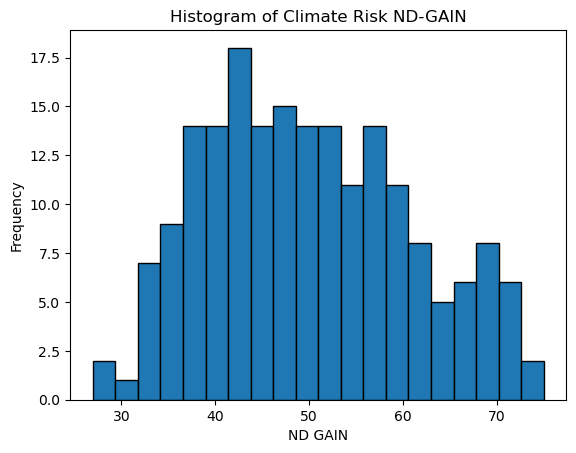

In [23]:
import matplotlib.pyplot as plt

# Extract the 'INDEX 2050 Pessimistic' values
index_2050_values = local_climate_risk['Local Climate Risk']

# Create a histogram
plt.hist(index_2050_values, bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('ND GAIN')
plt.ylabel('Frequency')
plt.title('Histogram of Climate Risk ND-GAIN')

# Show the plot
plt.show()

## X/Y Graph

Getting an indicator to compare

In [165]:
import numpy as np

df=resulting_dataframe_country_inputs_leontief[0]

# Filter rows where Development is 'Developed'
developed_countries = df[df['Development'] == 'Developed']

# Calculate the 90th percentile of 'High Risk' in developed countries
high_risk_90th_percentile = np.percentile(developed_countries['High Risk'], 75)

print("90th percentile of High Risk in developed countries:", high_risk_90th_percentile)

import numpy as np

# Filter rows where Development is 'Developing'
developing_countries = df[df['Development'] == 'Developing']

# Filter rows where Development is 'Least Developed'
ldc_countries = df[df['Development'] == 'Least Developed']

# Concatenate the dataframes for developing and least developed countries
developing_ldc_countries = pd.concat([developing_countries, ldc_countries])

# Calculate the median of 'High Risk' for developing and least developed countries together
high_risk_median_developing_ldc = np.median(df['High Risk'])

print("Median of High Risk in developing and least developed countries together:", high_risk_median_developing_ldc)

90th percentile of High Risk in developed countries: 5.797756774647825
Median of High Risk in developing and least developed countries together: 5.836616849716054


Comparing with changing threshold

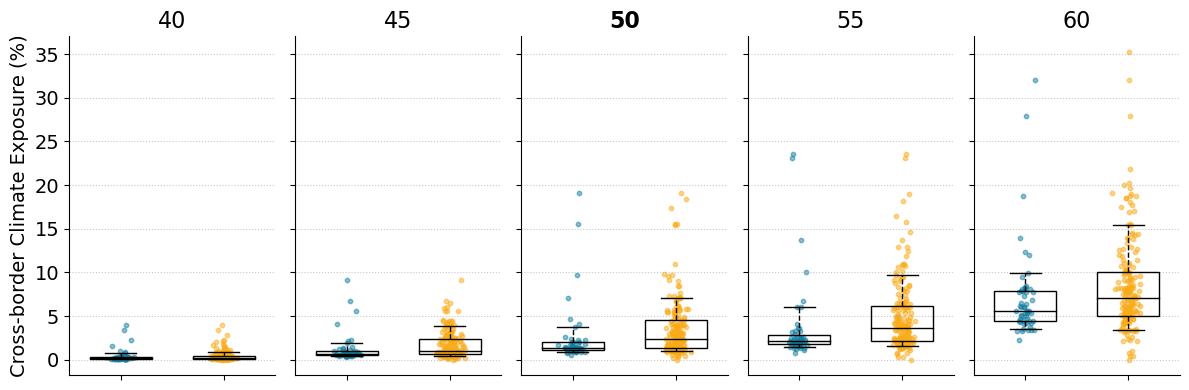

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import numpy as np
plt.rcdefaults()
# Lists to store t values and data for developed and non-developed countries
t_values = [40, 45, 50, 55, 60]
data_developed = []
data_not_developed = []

# Custom colors
colors = ['#1380A1', '#FAAB18']  # Orange for Developed, Blue for Developing/Least Developed

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_inputs_leontief[t]
    
    # Filter data
    developed_data = df_t[df_t['Development'] == 'Developed']['High Risk Exposure (%)'].tolist()
    #not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk'].tolist()
    not_developed_data = df_t['High Risk Exposure (%)'].tolist()
    
    # Append data for plotting
    data_developed.append(developed_data)
    data_not_developed.append(not_developed_data)

# Define the figure and a single row of axes
fig, axes = plt.subplots(nrows=1, ncols=len(t_values), figsize=(12,4), sharey=True)  # Adjusted for a single row

# Plot data in subplots
for idx, ax in enumerate(axes):
    # Plot boxplot for developed countries
    ax.boxplot(data_developed[idx], positions=[1], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor='none', color='black'),
               medianprops=dict(color="black"),
               whiskerprops=dict(color='black', linestyle='--'),
               capprops=dict(color='black'),
               flierprops=dict(marker='o', markerfacecolor=colors[0], markersize=5, markeredgecolor='black'),
               showfliers=False, whis=[10, 90])
    
    # Plot boxplot for non-developed countries
    ax.boxplot(data_not_developed[idx], positions=[2], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor='none', color='black'),
               medianprops=dict(color="black"),
               whiskerprops=dict(color='black', linestyle='--'),
               capprops=dict(color='black'),
               flierprops=dict(marker='o', markerfacecolor=colors[1], markersize=5, markeredgecolor='black'),
               showfliers=False, whis=[10, 90])
    
    # Add jittered scatter plot for developed countries
    jitter = np.random.normal(1, 0.05, size=len(data_developed[idx]))
    ax.scatter(jitter, data_developed[idx], color=colors[0], alpha=0.5, s=10)

    # Add jittered scatter plot for non-developed countries
    jitter = np.random.normal(2, 0.05, size=len(data_not_developed[idx]))
    ax.scatter(jitter, data_not_developed[idx], color=colors[1], alpha=0.5, s=10)

    # Set x-ticks and labels off
    ax.set_xticklabels([])

    # Set the title for each subplot
    if t_values[idx]==50:
        ax.set_title(f'{t_values[idx]}', size=16,fontweight='bold')
    else:
        ax.set_title(f'{t_values[idx]}', size=16)


    # Configure y-ticks and labels
    ax.tick_params(axis='y', labelsize=14)
    if idx == 0:
        ax.set_ylabel('Cross-border Climate Exposure (%)', size=14)

    # Only enable y-axis grid and remove x-axis grid for clarity
    ax.yaxis.grid(True, linestyle=':', alpha=0.7)
    ax.xaxis.grid(False)

    # Hide the top and right spines to reduce visual clutter
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Make spines darker
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('black')

# Define custom legend for the scatter points
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Developed (N={len(developed_data)})',
           markerfacecolor='#FAAB18', markersize=10),
    Line2D([0], [0], marker='o', color='w',
           label=f'Developing/Least Developed (N={len(not_developed_data)})',
           markerfacecolor='#1380A1', markersize=10)
]

# Add the legend to the figure, not to the individual axes
#fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.2, 1), ncol=2, fontsize=14, frameon=False)

plt.tight_layout()

# Save the plot to a file
plt.savefig(r'Figures\Supp Mat\E\Figure2b.png')

# Display the plot
plt.show()

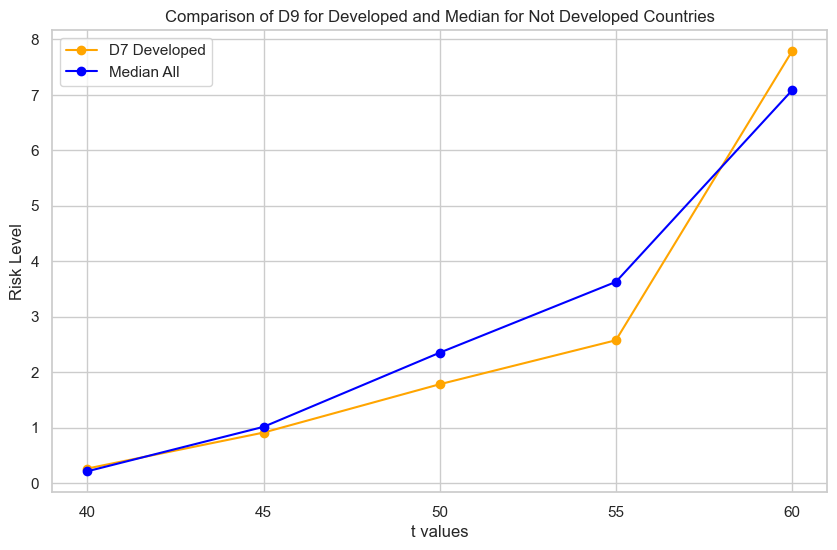

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Lists to store t values
t_values = [40,45,50,55,60]
d_developed = []
median_all = []

# Iterate over t values
for t in t_values:
    df_t = resulting_dataframe_country_inputs_leontief[t]
    
    # Filter data
    developed_data = df_t[df_t['Development'] == 'Developed']['High Risk Exposure (%)']
    #not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk']
    all_data = df_t['High Risk Exposure (%)']

    # Check if there is any data to process and calculate D9 for developed and median for not developed
    if not developed_data.empty:
        d_developed.append(np.percentile(developed_data, 70))
    else:
        d_developed.append(np.nan)  # Append NaN if no data
    
    if not all_data.empty:
        median_all.append(np.median(all_data))
    else:
        median_all.append(np.nan)  # Append NaN if no data

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(t_values, d_developed, marker='o', linestyle='-', color='orange', label='D7 Developed')
plt.plot(t_values, median_all, marker='o', linestyle='-', color='blue', label='Median All')

# Adding labels and title
plt.xlabel('t values')
plt.ylabel('Risk Level')
plt.title('Comparison of D9 for Developed and Median for Not Developed Countries')
plt.xticks(t_values)
plt.grid(True)

# Adding a legend
plt.legend()

# Show the plot
plt.show()

Comparing with taking one country out at a time

In [191]:
# Lists to store t values, 80th percentiles for developed countries, and median for all countries
risky_countries = risk_level_lists_MRIOT['MR'] + risk_level_lists_MRIOT['HR'] + risk_level_lists_MRIOT['VHR']
positive_difference_countries = []

# Iterate over risky countries
for c in risky_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    
    # Calculate the 75th percentile of 'High Risk' in developed countries
    high_risk_75th_percentile = np.percentile(developed_countries['High Risk'], 70)
    
    # Calculate the median of 'High Risk' for all countries
    high_risk_median = np.median(df_c['High Risk'])
    
    # Calculate the difference
    difference = high_risk_75th_percentile - high_risk_median
    
    # Check if the difference is positive
    if difference > 0:
        positive_difference_countries.append(c)

# Print the countries where the difference is positive
print("Countries where the difference between 75th Percentile of Developed Countries and Median of All Countries is positive:")
for country in positive_difference_countries:
    print(country)

Countries where the difference between 75th Percentile of Developed Countries and Median of All Countries is positive:


## Correlation Graph

Plot Graph

A graph with threshold on x axis and R2 and p value on y axis

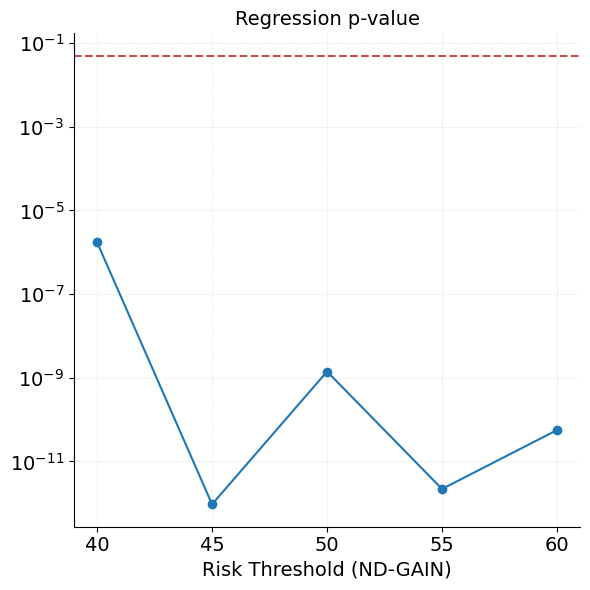

In [107]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store t values, p-values, and R-squared values
t_values = [40,45,50,55,60]
p_values = []

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_inputs_leontief[t]
    df_t = df_t.dropna(subset=['Local Climate Risk'])

    # Extracting the columns for regression
    x = df_t['Local Climate Risk']
    y = df_t['Share of Risky Trade Partners (%)']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append p-value to list
    p_values.append(p_value)

# Convert lists to numpy arrays
t_values = np.array(t_values)
p_values = np.array(p_values)

# Plotting P-values vs. t
plt.figure(figsize=(6, 6))
plt.plot(t_values, p_values, marker='o', linestyle='-')
plt.xlabel('Risk Threshold (ND-GAIN)',fontsize=14)
plt.ylabel('')
plt.title('Regression p-value',fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

plt.yscale('log')  # Setting logarithmic scale on y-axis
plt.axhline(y=0.05, color='r', linestyle='--')  # Add horizontal line at y = 0.05 in red

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label

plt.tight_layout()

# Save the plot to a file
plt.savefig(r'Figures\Supp Mat\E\Figure4d.png')


plt.show()

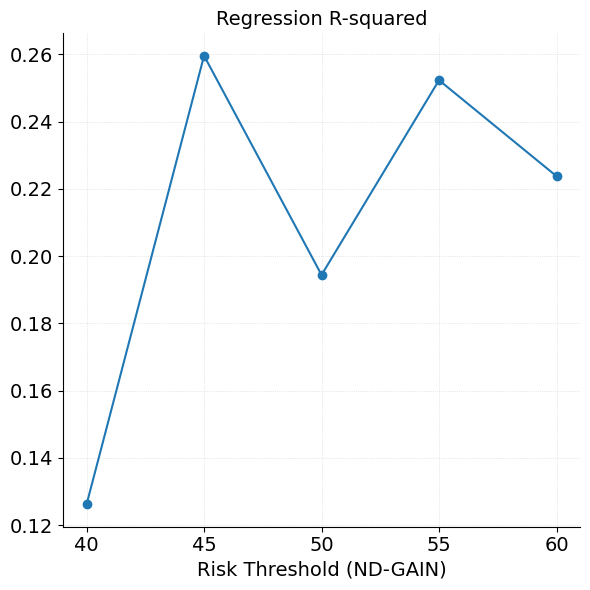

In [108]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store t values and R-squared values
t_values = [40,45,50,55,60]
r_squared_values = []

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_inputs_leontief[t]
    df_t = df_t.dropna(subset=['Local Climate Risk'])
    
    # Extracting the columns for regression
    x = df_t['Local Climate Risk']
    y = df_t['Share of Risky Trade Partners (%)']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append R-squared value to list
    r_squared_values.append(r_value**2)

# Convert lists to numpy arrays
t_values = np.array(t_values)
r_squared_values = np.array(r_squared_values)

# Plotting R-squared values vs. t
plt.figure(figsize=(6, 6))
plt.plot(t_values, r_squared_values, marker='o', linestyle='-')
plt.xlabel('Risk Threshold (ND-GAIN)',fontsize=14)
plt.ylabel('')
plt.title('Regression R-squared',fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label

# Save the plot to a file
plt.savefig(r'Figures\Supp Mat\E\Figure4c.png')


plt.tight_layout()
plt.show()

In [98]:
# Sort the list by p-value
sorted_by_p_value = sorted(country_data, key=lambda x: x[1], reverse=True)
# Sort the list by R-squared value
sorted_by_r_squared = sorted(country_data, key=lambda x: x[2])

# Print the top 10 countries with the highest p-values
print("Top 10 countries with highest p-values:")
for i, (country, p_value, r_squared) in enumerate(sorted_by_p_value[:10], 1):
    print(f"{i}. {country}: p-value = {p_value}, R-squared = {r_squared}")

# Print the top 10 countries with the lowest R-squared values
print("\nTop 10 countries with lowest R-squared values:")
for i, (country, p_value, r_squared) in enumerate(sorted_by_r_squared[:10], 1):
    print(f"{i}. {country}: p-value = {p_value}, R-squared = {r_squared}")

Top 10 countries with highest p-values:
1. IND: p-value = 1.3856643983794522e-05, R-squared = 0.10094627960311009
2. IRN: p-value = 6.706850775388117e-06, R-squared = 0.10794035460814383
3. ZAF: p-value = 3.999986293804819e-06, R-squared = 0.1129005202795584
4. CHN: p-value = 3.6911241862229196e-06, R-squared = 0.11367008128290237
5. KEN: p-value = 3.0882012444404887e-06, R-squared = 0.11537633398174095
6. CIV: p-value = 2.1524305315180896e-06, R-squared = 0.11882306281479248
7. VNM: p-value = 2.0804492872282463e-06, R-squared = 0.11914733768913935
8. NGA: p-value = 1.9589760907874138e-06, R-squared = 0.11972069144622961
9. ZMB: p-value = 1.880073991825949e-06, R-squared = 0.1201123316017525
10. LBN: p-value = 1.5803331182287717e-06, R-squared = 0.12176546556378744

Top 10 countries with lowest R-squared values:
1. IND: p-value = 1.3856643983794522e-05, R-squared = 0.10094627960311009
2. IRN: p-value = 6.706850775388117e-06, R-squared = 0.10794035460814383
3. ZAF: p-value = 3.999986293

## Histogram

Graphically

In [92]:
resulting_dataframe_country_inputs_leontief[60]

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%),Share of Risky Trade Partners (%) Category,Foreign (%) Category
0,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,23.441678,33.413858,0,58.516092,41.483908,58.769753,High-risk suppliers,Foreign-oriented
1,Hong Kong,HKG,58.324542,Low Risk,East Asia & Pacific,High income,7350409.0,Developing,20.157398,37.183448,0,57.354527,42.645473,64.846353,High-risk suppliers,Foreign-oriented
2,San Marino,SMR,60.117865,Low Risk,Europe & Central Asia,High income,33642.0,Developed,16.014282,34.479335,0,51.006468,48.993532,68.284542,High-risk suppliers,Foreign-oriented
3,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,24.127290,23.969949,0,48.111373,51.888627,49.836435,High-risk suppliers,Foreign-oriented
4,Luxembourg,LUX,68.424627,Low Risk,Europe & Central Asia,High income,657569.0,Developed,41.661382,5.199668,0,46.874044,53.125956,11.095927,Low-risk suppliers,Foreign-oriented
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,Somalia,SOM,33.752517,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.641047,1.042990,0,1.714303,98.285697,61.933899,High-risk suppliers,Locally-oriented
175,South Sudan,SDS,32.845793,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.617452,0.871398,0,1.527666,98.472334,58.528258,High-risk suppliers,Locally-oriented
176,Guyana,GUY,44.952938,High Risk,Latin America & Caribbean,High income,813834.0,Developing,0.769828,0.454908,0,1.225018,98.774982,37.143363,Low-risk suppliers,Locally-oriented
177,Myanmar,MMR,37.686660,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.390757,0.420921,0,0.824747,99.175253,51.858180,High-risk suppliers,Locally-oriented


C:\Users\delah\AppData\Local\Temp\ipykernel_13240\3767259703.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()


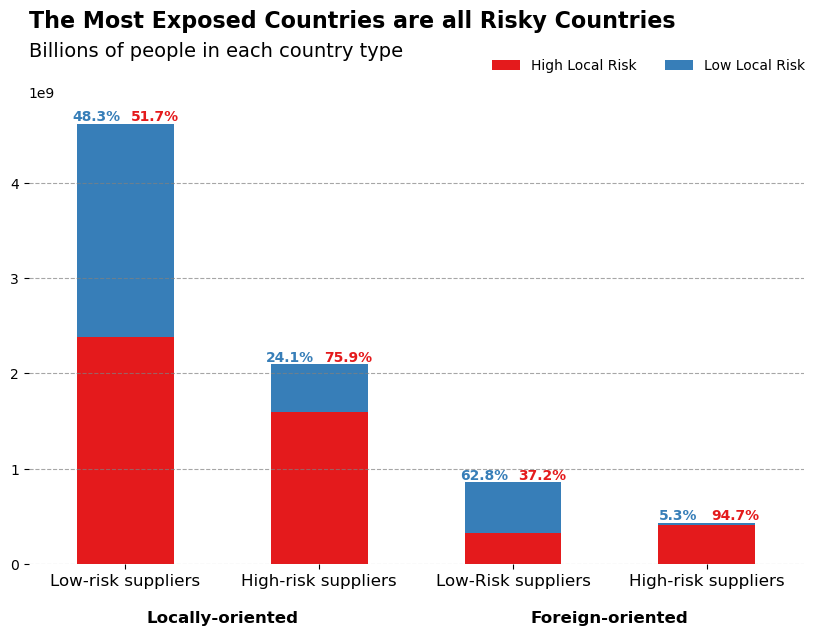

In [13]:
import seaborn as sns

t=50
df = resulting_dataframe_country_inputs_leontief[t]
df = df.dropna(subset=['Local Climate Risk'])

median_high_risk_imports = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'Share of Risky Trade Partners (%) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=10,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=12)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=12,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.12), ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

# Show the plot
#plt.tight_layout()
plt.show()

In [96]:
df = resulting_dataframe_country_inputs_leontief[60]
df[(df['Share of Risky Trade Partners (%) Category']=='High-risk suppliers')&(df['Foreign (%) Category']=='Foreign-oriented')].sort

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%),Share of Risky Trade Partners (%) Category,Foreign (%) Category
0,"Moldova, Republic of",MDA,51.757501,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,23.441678,33.413858,0,58.516092,41.483908,58.769753,High-risk suppliers,Foreign-oriented
1,Hong Kong,HKG,58.324542,Low Risk,East Asia & Pacific,High income,7350409.0,Developing,20.157398,37.183448,0,57.354527,42.645473,64.846353,High-risk suppliers,Foreign-oriented
2,San Marino,SMR,60.117865,Low Risk,Europe & Central Asia,High income,33642.0,Developed,16.014282,34.479335,0,51.006468,48.993532,68.284542,High-risk suppliers,Foreign-oriented
3,Singapore,SGP,71.506500,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,24.127290,23.969949,0,48.111373,51.888627,49.836435,High-risk suppliers,Foreign-oriented
5,Viet Nam,VNM,47.525898,High Risk,East Asia & Pacific,Lower middle income,98858950.0,Developing,24.836123,20.703887,0,45.558563,54.441437,45.463071,High-risk suppliers,Foreign-oriented
6,Djibouti,DJI,42.581724,High Risk,Middle East & North Africa,Lower middle income,1136455.0,Least Developed,24.064169,20.969226,0,45.285636,54.714364,46.563725,High-risk suppliers,Foreign-oriented
9,Maldives,MDV,45.772272,High Risk,South Asia,Upper middle income,521021.0,Developing,23.166006,17.955143,0,41.248466,58.751534,43.664011,High-risk suppliers,Foreign-oriented
11,Liberia,LBR,34.087161,High Risk,Sub-Saharan Africa,Low income,5418377.0,Least Developed,17.206130,19.163225,0,36.805121,63.194879,52.690583,High-risk suppliers,Foreign-oriented
12,Malaysia,MYS,56.915815,Low Risk,East Asia & Pacific,Upper middle income,34308525.0,Developing,22.036946,14.703610,0,36.753289,63.246711,40.020108,High-risk suppliers,Foreign-oriented
13,Montenegro,MNE,54.912147,Low Risk,Europe & Central Asia,Upper middle income,615737.0,Developed,14.995574,20.548018,0,36.138652,63.861348,57.810753,High-risk suppliers,Foreign-oriented


In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'Share of Risky Trade Partners (%) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Calculate the percentage of the population in 'High Local Risk' category among 'High-risk suppliers' and 'Foreign-oriented'
total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100

C:\Users\delah\AppData\Local\Temp\ipykernel_24464\2971347820.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\2971347820.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_24464\2971347820.py:24: FutureWarning: The default o

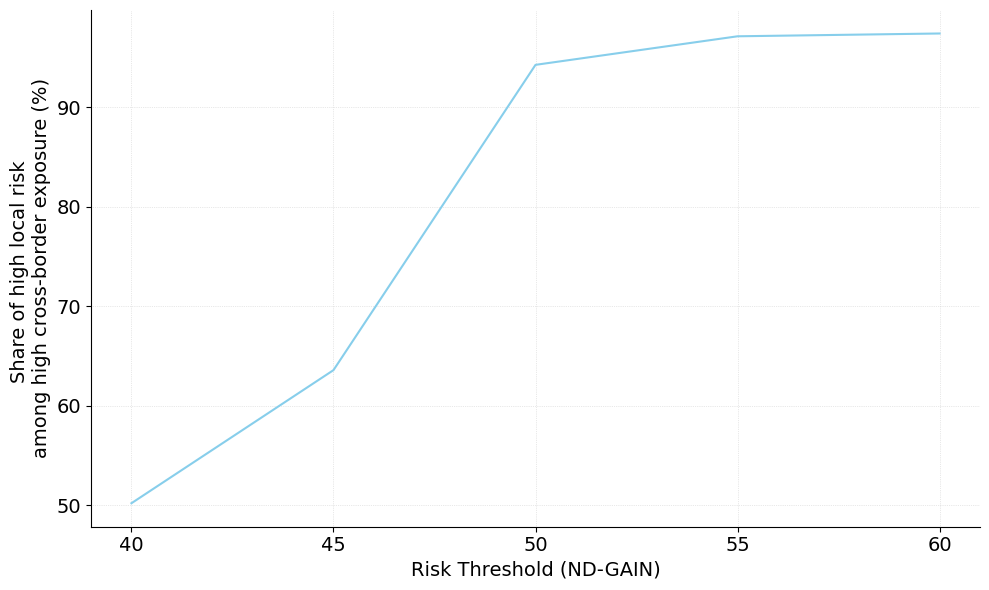

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store t values and the final percentage for each t
t_values =[40,45,50,55,60]
percentages = []

# Iterate over each t
for t in t_values:
    # Set df to resulting_dataframe_country_inputs_leontief[t]
    df = resulting_dataframe_country_inputs_leontief[t]
    # Calculate the median values for 'High Risk (imports)' and 'Foreign (%)'
    median_high_risk_imports = df['Share of Risky Trade Partners (%)'].median()
    median_foreign = df['Foreign (%)'].median()

    # Add columns to indicate if each row is over or under the median for the specified columns
    df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
    df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

    # Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'Share of Risky Trade Partners (%) Category'
    df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

    # Group the sorted data
    grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

    # Unstack the 'Local Risk' level to prepare for a stacked bar chart
    population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

    # Define the custom order
    custom_order = [
        ('Locally-oriented', 'Low-risk suppliers'),
        ('Locally-oriented', 'High-risk suppliers'),
        ('Foreign-oriented', 'Low-risk suppliers'),
        ('Foreign-oriented', 'High-risk suppliers'),
    ]

    # Reorder the DataFrame according to the custom order
    population_by_risk = population_by_risk.loc[custom_order]

    # Calculate the percentage of the population in 'High Local Risk' category among 'High-risk suppliers' and 'Foreign-oriented'
    total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
    total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
    percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100
    
    # Append t and the final percentage to the lists
    percentages.append(percentage_high_local_risk)

# Plot using a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.plot(t_values, percentages, color='skyblue')
plt.ylabel('Share of high local risk \namong high cross-border exposure (%)',size=14)
plt.xlabel('Risk Threshold (ND-GAIN)',size=14)


#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label

# Adjust x-ticks to show 3.5 + t
new_labels = [f'{t:.0f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

plt.tight_layout()
plt.savefig(r'Figures\Supp Mat\E\Figure3b.png')

plt.show() 

In [8]:
df=resulting_dataframe_country_inputs_leontief[50]
df[(df['Share of Risky Trade Partners (%) Category'] == 'High-risk suppliers') &
   (df['Foreign (%) Category'] == 'Foreign-oriented')].sort_values(by='Population',ascending = False)

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%),Share of Risky Trade Partners (%) Category,Foreign (%) Category
51,Ethiopia,ETH,37.492203,High Risk,Sub-Saharan Africa,Low income,126527060.0,Least Developed,20.393094,5.896192,0,26.366562,73.633438,22.428118,High-risk suppliers,Foreign-oriented
74,Iraq,IRQ,43.000278,High Risk,Middle East & North Africa,Upper middle income,45504560.0,Developing,19.930743,4.077605,0,24.023978,75.976022,16.984112,High-risk suppliers,Foreign-oriented
63,Ghana,GHA,44.860355,High Risk,Sub-Saharan Africa,Lower middle income,34121985.0,Developing,21.255873,4.100984,0,25.384070,74.615930,16.173078,High-risk suppliers,Foreign-oriented
30,Mozambique,MOZ,38.504607,High Risk,Sub-Saharan Africa,Low income,33897354.0,Least Developed,14.895930,15.564364,0,30.520252,69.479748,51.097222,High-risk suppliers,Foreign-oriented
88,Mali,MLI,34.612620,High Risk,Sub-Saharan Africa,Low income,23293698.0,Least Developed,16.844060,4.859543,0,21.750512,78.249488,22.390489,High-risk suppliers,Foreign-oriented
65,Sri Lanka,LKA,46.555819,High Risk,South Asia,Lower middle income,22241304.0,Developing,17.748803,7.212619,0,24.975383,75.024617,28.895064,High-risk suppliers,Foreign-oriented
64,Malawi,MWI,37.618372,High Risk,Sub-Saharan Africa,Low income,20931751.0,Least Developed,13.915578,10.999358,0,25.022940,74.977060,44.147647,High-risk suppliers,Foreign-oriented
8,Guinea,GIN,38.096937,High Risk,Sub-Saharan Africa,Lower middle income,14190612.0,Least Developed,35.273654,6.204781,0,41.618436,58.381564,14.959054,High-risk suppliers,Foreign-oriented
87,Burundi,BDI,35.486819,High Risk,Sub-Saharan Africa,Low income,13238559.0,Least Developed,15.754465,5.682984,0,21.771737,78.228263,26.509611,High-risk suppliers,Foreign-oriented
83,Haiti,HTI,35.528924,High Risk,Latin America & Caribbean,Lower middle income,11724763.0,Least Developed,19.086512,3.425921,0,22.591317,77.408683,15.217907,High-risk suppliers,Foreign-oriented
